In [ ]:
import uproot
import pandas as pd
import os

root_path = "/mnt/mydisk/WCDA_simulation/" # WCDA_simulation folder

file_path = []
for filename in os.listdir(root_path):
	full_path = os.path.join(root_path, filename)
	file_path.append(full_path)


In [21]:
# check head 5
print(len(file_path))
for i in range(5):
	print(file_path[i])

10002
/mnt/mydisk/WCDA_simulation/Egr000007744_01_n0010_eventout.root
/mnt/mydisk/WCDA_simulation/Egr000009185_01_n0010_eventout.root
/mnt/mydisk/WCDA_simulation/Egr000002598_01_n0010_eventout.root
/mnt/mydisk/WCDA_simulation/Egr000002530_01_n0010_eventout.root
/mnt/mydisk/WCDA_simulation/Egr000008875_01_n0010_eventout.root


### 开第一个root文件，看看文件格式

In [2]:
# 打开第一个root文件，看看文件格式
file = uproot.open(file_path[0])
print(f"================ {file_path[0]} 内容概览 ================")
# 1. 显示文件中的所有对象
print("\n文件中的对象列表:")
for key in file.keys():
    print(f"  - {key}")

# 2. 查看TTree的详细信息
for path, obj in file.items():
    if isinstance(obj, uproot.TTree):
        print(f"\n>>> 树: {path} <<<")
        print(f"总条目数: {obj.num_entries}")
        
        # 显示分支信息
        print("\n分支结构:")
        for branch_name in obj.keys():
            branch = obj[branch_name]
            print(f"  - {branch_name.ljust(30)} {str(branch.typename).ljust(20)}")
        
      #   # 显示前几行数据
      #   print("\n前3行数据示例:")
      #   print(obj.arrays(library="pd", entry_stop=3))

================ /mnt/mydisk/WCDA_simulation/Egr000007744_01_n0010_eventout.root 内容概览 ================

文件中的对象列表:
  - t_eventout_h;1
  - t_eventout;1

>>> 树: t_eventout_h;1 <<<
总条目数: 1

分支结构:
  - mtime                          std::string         
  - filename                       std::string         
  - infiles                        std::string         
  - texts                          std::string         

>>> 树: t_eventout;1 <<<
总条目数: 3790

分支结构:
  - n                              int32_t             
  - nfit0                          int32_t             
  - nfit                           int32_t             
  - nfitb                          int32_t             
  - vnfit                          int32_t[4]          
  - fitstat                        int32_t             
  - nrange                         int32_t             
  - nv                             int32_t             
  - vflag                          int32_t[]           
  - vidmc                          in

In [3]:
with uproot.open(file_path[0]) as file:
    # Read the header tree
    tree_head = file["t_eventout_h;1"]
    head_data = tree_head.arrays(library="pd")
    
    # Extract the texts field which contains variable explanations
    if "texts" in head_data.columns:
        explanations = head_data["texts"].iloc[0]
        print(explanations)
    else:
        print("No 'texts' field found in the header tree")


############### EXPLANATIONS TO THE VARIABLES ###############
# Note: Unit of angle or direction is radian                #
#       Unit of distance or position is meter               #
#       Unit of time is ns                                  #
#############################################################
- n/I: number of hits before noise filter
- nfit0/I: number of hits on plateau
- nfit/I: number of fitted hits
- nfitb/I: number of fitted hits with qsamp >= 0.5
- vnfit[4]/I: number of fitted hits in pool 1-4 with qsamp >= 0.5
- fitstat/I: status of the fitting, 0 is normal
- nrange/I: number of hits in +/- 60 ns around the corrected shower plane
- nv/I: number of stored (i.e., in range) hits
- vflag[nv]/I: flag of the hit
- vidmc[nv]/I: id in MC style of the hit
- vx[nv]/F: x of the hit in shower plane
- vy[nv]/F: y of the hit in shower plane
- vt[nv]/F: t of the hit to corrected shower front
- vnpe[nv]/F: number of photon-electrons of the hit
- vq[nv]/F: charge in normalized SP

In [4]:
# 转换为 pandas DataFrame（前3条）
tree = file["t_eventout;1"]
df = tree.arrays(library="pd")
df.head(5)

,n,nfit0,nfit,nfitb,vnfit,fitstat,nrange,nv,vflag,vidmc,...,f5w,mc_weight,mc_pid,mc_energy,mc_theta,mc_phi,mc_xc,mc_yc,mc_dangle,mc_dcore
0,481,291,278,161,[0 0 82 79],0,360,360,"[111122738, 111122893, 111122515, 111122582, 1...","[2738, 2893, 2515, 2582, 2426, 2156, 2671, 215...",...,0.155250,400.000000,1,83.843323,0.515431,4.627849,94.171514,196.258887,0.267889,131.445242
1,198,34,41,23,[2 0 2 19],0,70,70,"[101110242, 101110273, 101110244, 101010070, 1...","[242, 273, 244, 70, 1477, 1875, 1910, 864, 599...",...,0.000000,385.907135,1,129.779495,0.373653,4.466936,-51.565527,105.482451,0.009453,9.293928
2,353,108,98,78,[73 2 0 3],0,121,121,"[-101072987, -101062273, -101062388, 111111899...","[2987, 2273, 2388, 1899, 2094, 2451, 2158, 217...",...,0.649315,385.907135,1,235.224854,0.299750,1.499869,-96.887217,-59.686177,0.023285,3.842429
3,240,44,44,21,[2 1 3 15],0,83,83,"[101021006, 101111148, 101111067, 101111127, 1...","[1006, 1148, 1067, 1127, 1041, 924, 860, 952, ...",...,0.000000,385.907135,1,180.266251,0.259753,5.153257,-29.157620,65.511226,0.004337,11.891446
4,292,58,55,27,[0 4 23 0],0,92,92,"[101111753, 101111787, -101071796, 101121632, ...","[1753, 1787, 1796, 1632, 1723, 2991, 3044, 299...",...,0.000000,385.907135,1,140.704208,0.212943,6.144849,54.233281,37.334617,0.021279,8.967247


### 一些疑问？
1. mc_weight是什么？
3. vnpe[], vq[], vqsamp[]: 光电倍增管信号和电荷信息?具体是啥？感觉用vq更合适
4. mc_pid 1代表质子还是伽马？看起来1代表伽马？

### 分析查看一下数据格式和分布

该文件下有event数： 3790
每个event的参数量有： 38


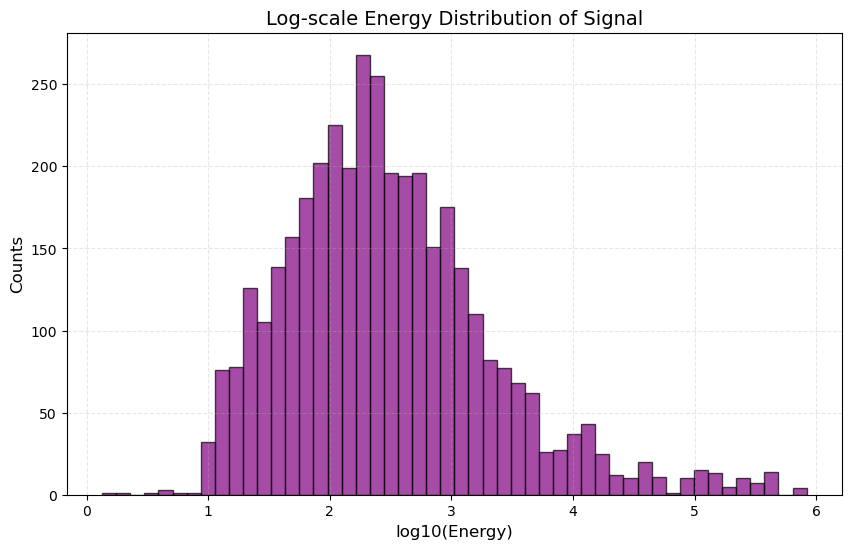

In [6]:
import uproot
import matplotlib.pyplot as plt
import numpy as np

# 打开 ROOT 文件并读取数据
with uproot.open(file_path[0]) as file:
    tree = file["t_eventout;1"]
    print(f"该文件下有event数： {tree.num_entries}")
    print(f"每个event的参数量有： {len(tree)}")
    energies = tree["mc_energy"].array()  # 读取所有事件的 energy 分支
    

# 绘制直方图
plt.figure(figsize=(10, 6))
plt.hist(np.log10(energies), bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.xlabel("log10(Energy)", fontsize=12)
plt.ylabel("Counts", fontsize=12)
plt.title("Log-scale Energy Distribution of Signal", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()



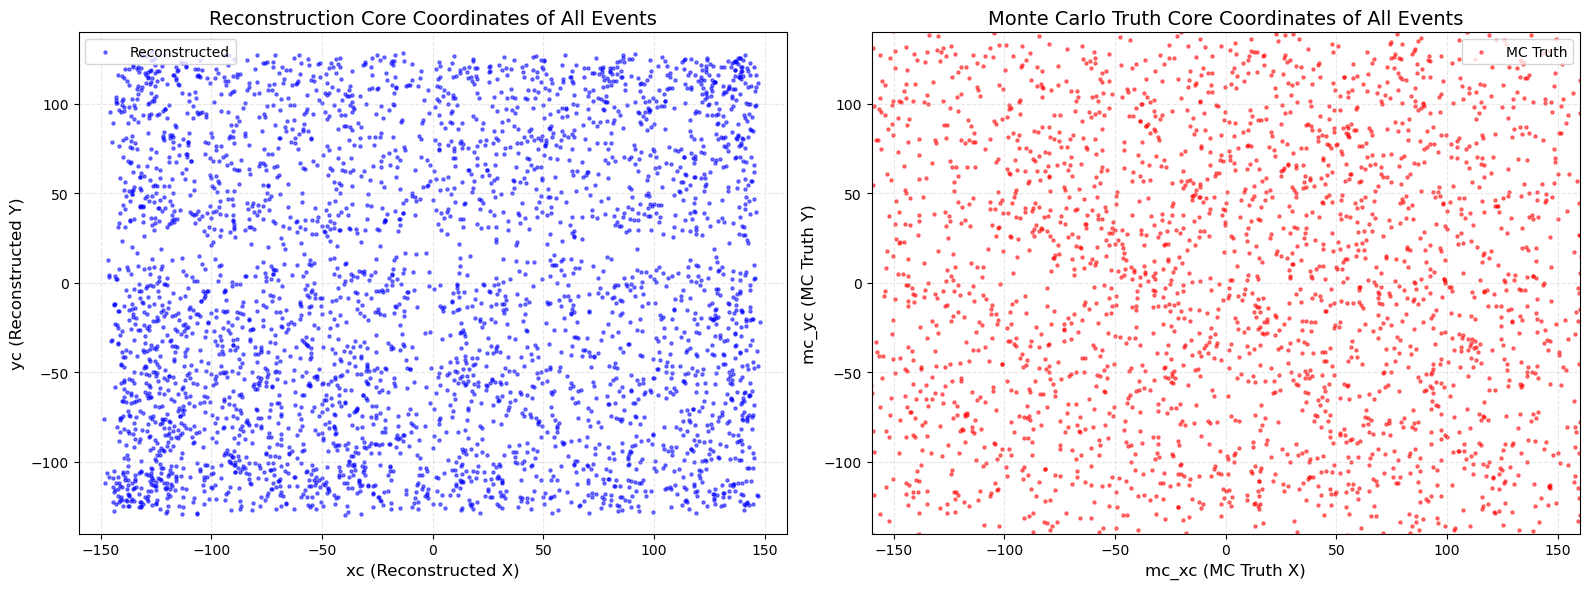

In [7]:
import uproot
import matplotlib.pyplot as plt
import numpy as np

# 打开文件并读取数据
with uproot.open(file_path[0]) as file:
    tree = file["t_eventout;1"]
    data = tree.arrays(["xc", "yc", "mc_xc", "mc_yc"], library="pd")

# 创建画布
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 设置固定的坐标范围
x_limits = [-160, 160]
y_limits = [-140, 140]

# (1) 重建坐标 xc vs yc
ax1.scatter(data["xc"], data["yc"], s=5, alpha=0.5, color='blue', label="Reconstructed")
ax1.set_xlabel("xc (Reconstructed X)", fontsize=12)
ax1.set_ylabel("yc (Reconstructed Y)", fontsize=12)
ax1.set_title("Reconstruction Core Coordinates of All Events", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend()
# 设置坐标范围
ax1.set_xlim(x_limits)
ax1.set_ylim(y_limits)

# (2) MC 真值坐标 mc_xc vs mc_yc
ax2.scatter(data["mc_xc"], data["mc_yc"], s=5, alpha=0.5, color='red', label="MC Truth")
ax2.set_xlabel("mc_xc (MC Truth X)", fontsize=12)
ax2.set_ylabel("mc_yc (MC Truth Y)", fontsize=12)
ax2.set_title("Monte Carlo Truth Core Coordinates of All Events", fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.legend()
# 设置坐标范围
ax2.set_xlim(x_limits)
ax2.set_ylim(y_limits)

plt.tight_layout()
plt.show()

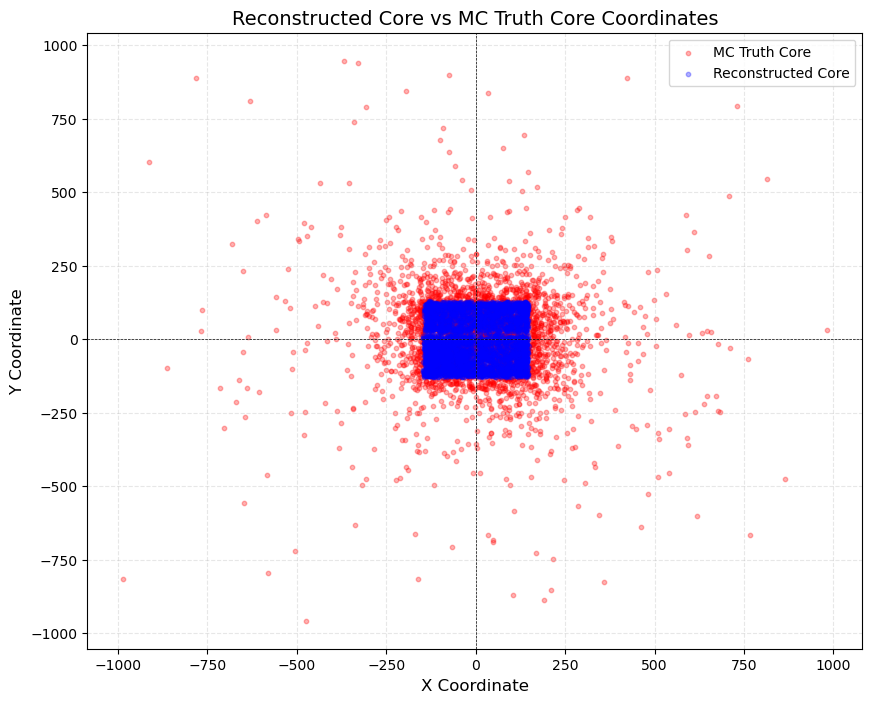

In [8]:
plt.figure(figsize=(10, 8))
plt.scatter(data["mc_xc"], data["mc_yc"], s=10, alpha=0.3, color='red', label="MC Truth Core")
plt.scatter(data["xc"], data["yc"], s=10, alpha=0.3, color='blue', label="Reconstructed Core")

# 标记坐标原点
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.axvline(0, color='black', linestyle='--', linewidth=0.5)

plt.xlabel("X Coordinate", fontsize=12)
plt.ylabel("Y Coordinate", fontsize=12)
plt.title("Reconstructed Core vs MC Truth Core Coordinates", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


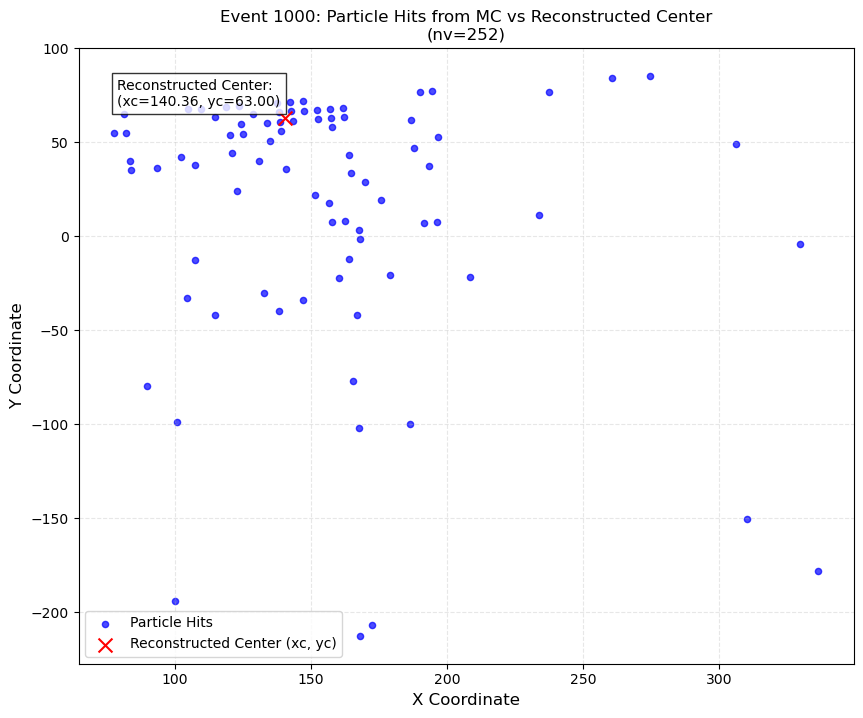

In [13]:
with uproot.open(file_path[0]) as file:
    tree = file["t_eventout;1"]
    
    # 读取第一个事件的变量
    event_index = 1000  # 选择第任意事件
    nv = tree["n"].array()[event_index]  # 该事件的粒子数
    xc = tree["xc"].array()[event_index] # reconstruction的core坐标
    yc = tree["yc"].array()[event_index]
    vx = tree["vx"].array()[event_index]  # 这次事件触发的探测器的x坐标（截取前nv个）
    vy = tree["vy"].array()[event_index]  # 这次事件触发的探测器的y坐标

# 绘制散点图
plt.figure(figsize=(10, 8))
plt.scatter(vx+xc, vy+yc, s=20, alpha=0.7, color='blue', label="Particle Hits")
plt.scatter(xc, yc, s=100, color='red', marker='x', label="Reconstructed Center (xc, yc)")

# 标记坐标轴和标题
plt.xlabel("X Coordinate", fontsize=12)
plt.ylabel("Y Coordinate", fontsize=12)
plt.title(f"Event {event_index}: Particle Hits from MC vs Reconstructed Center\n(nv={nv})", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

# 添加文本标注
plt.text(0.05, 0.95, f"Reconstructed Center:\n(xc={xc:.2f}, yc={yc:.2f})", 
         transform=plt.gca().transAxes, verticalalignment='top', 
         bbox=dict(facecolor='white', alpha=0.8))


plt.show()

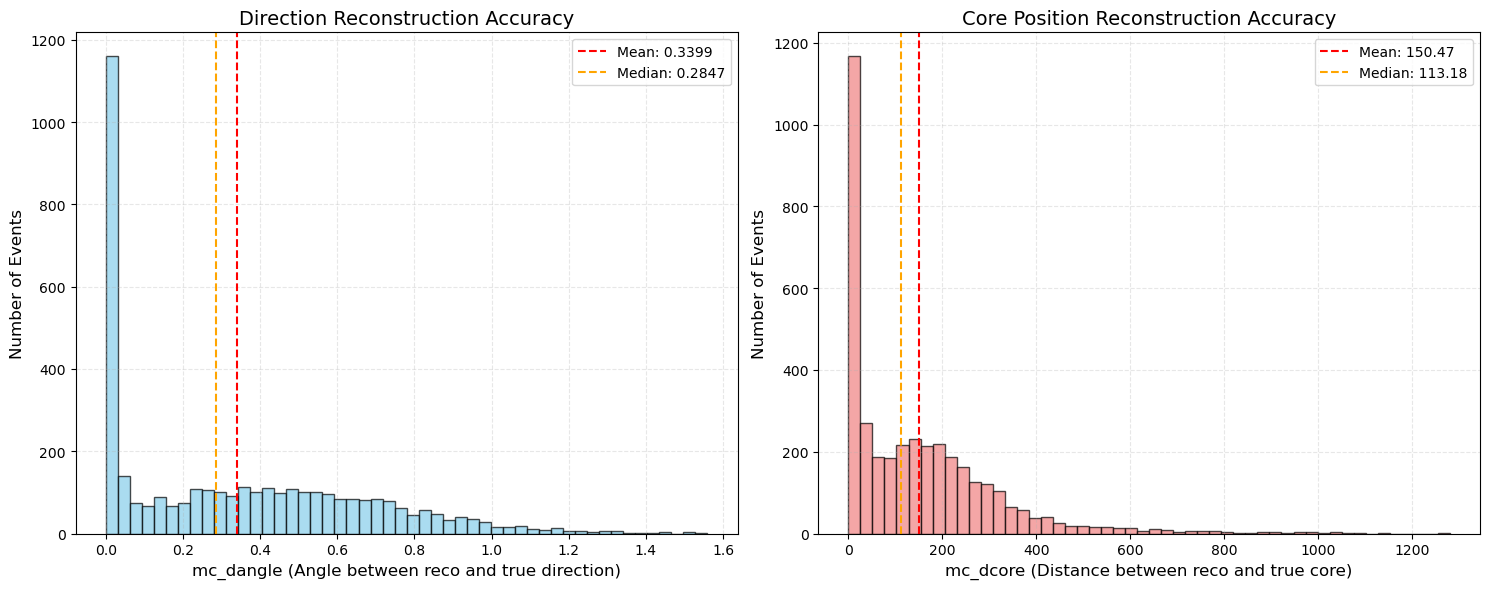

=== mc_dangle (Direction Reconstruction Accuracy) Statistics ===
Total events: 3790
Mean: 0.339928
Median: 0.284686
Standard deviation: 0.323652
Min: 0.000368
Max: 1.559334
90th percentile: 0.799393

=== mc_dcore (Core Position Reconstruction Accuracy) Statistics ===
Total events: 3790
Mean: 150.47
Median: 113.18
Standard deviation: 164.05
Min: 0.12
Max: 1281.24
90th percentile: 341.26


In [16]:
with uproot.open(file_path[0]) as file:
    tree = file["t_eventout;1"]
    mc_dangle = tree["mc_dangle"].array()
    mc_dcore = tree["mc_dcore"].array()
    

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# (1) mc_dangle distribution
ax1.hist(mc_dangle, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax1.set_xlabel("mc_dangle (Angle between reco and true direction)", fontsize=12)
ax1.set_ylabel("Number of Events", fontsize=12)
ax1.set_title("Direction Reconstruction Accuracy", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.3)

# Add statistics
mean_dangle = np.mean(mc_dangle)
median_dangle = np.median(mc_dangle)
ax1.axvline(mean_dangle, color='red', linestyle='--', label=f'Mean: {mean_dangle:.4f}')
ax1.axvline(median_dangle, color='orange', linestyle='--', label=f'Median: {median_dangle:.4f}')
ax1.legend()

# (2) mc_dcore distribution
ax2.hist(mc_dcore, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
ax2.set_xlabel("mc_dcore (Distance between reco and true core)", fontsize=12)
ax2.set_ylabel("Number of Events", fontsize=12)
ax2.set_title("Core Position Reconstruction Accuracy", fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.3)

# Add statistics
mean_dcore = np.mean(mc_dcore)
median_dcore = np.median(mc_dcore)
ax2.axvline(mean_dcore, color='red', linestyle='--', label=f'Mean: {mean_dcore:.2f}')
ax2.axvline(median_dcore, color='orange', linestyle='--', label=f'Median: {median_dcore:.2f}')
ax2.legend()

plt.tight_layout()
plt.show()

# Print detailed statistics
print("=== mc_dangle (Direction Reconstruction Accuracy) Statistics ===")
print(f"Total events: {len(mc_dangle)}")
print(f"Mean: {mean_dangle:.6f}")
print(f"Median: {median_dangle:.6f}")
print(f"Standard deviation: {np.std(mc_dangle):.6f}")
print(f"Min: {np.min(mc_dangle):.6f}")
print(f"Max: {np.max(mc_dangle):.6f}")
print(f"90th percentile: {np.percentile(mc_dangle, 90):.6f}")

print("\n=== mc_dcore (Core Position Reconstruction Accuracy) Statistics ===")
print(f"Total events: {len(mc_dcore)}")
print(f"Mean: {mean_dcore:.2f}")
print(f"Median: {median_dcore:.2f}")
print(f"Standard deviation: {np.std(mc_dcore):.2f}")
print(f"Min: {np.min(mc_dcore):.2f}")
print(f"Max: {np.max(mc_dcore):.2f}")
print(f"90th percentile: {np.percentile(mc_dcore, 90):.2f}")

In [19]:
# 检验mc_dcore == np.sqrt(data["x_error"]**2+data["y_error"]**2)  正确
np.sqrt((data["x_c"]-data["mc_xc"])**2+(data["y_c"]-data["mc_yc"]**2))

KeyError: 'x_c'

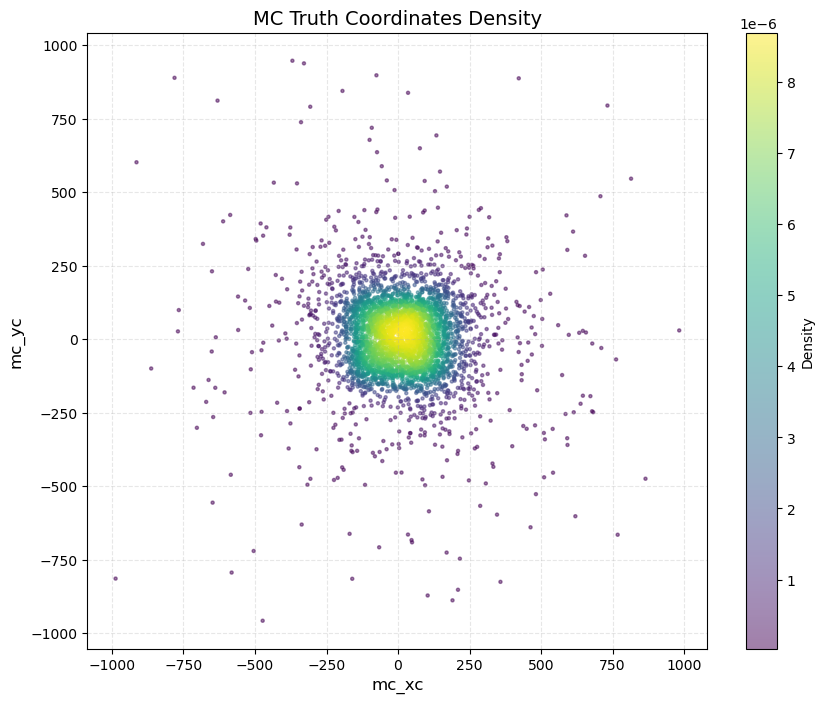

In [20]:
# 计算mc坐标的密度，即mc模拟中core落在何处的数量多，何处的数量少？
from scipy.stats import gaussian_kde

# 计算MC坐标的密度
xy = np.vstack([data["mc_xc"], data["mc_yc"]])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(10, 8))
plt.scatter(data["mc_xc"], data["mc_yc"], c=z, s=5, cmap='viridis', alpha=0.5)
plt.colorbar(label="Density")
plt.xlabel("mc_xc", fontsize=12)
plt.ylabel("mc_yc", fontsize=12)
plt.title("MC Truth Coordinates Density", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


In [21]:
# 以上所有的讨论都是针对file_path[0]文件的,一共有10002个文件,每个文件下的event数不是固定的，但都在3800上下
print(len(file_path))
with uproot.open(file_path[6159]) as file:
    tree = file["t_eventout;1"]
    print(f"该文件下有event数： {tree.num_entries}")
    print(f"每个event的参数量有： {len(tree)}")
    

10002
该文件下有event数： 3882
每个event的参数量有： 38


### 接下来尝试只使用file_path[0]的数据一共3790 events进行能量重建

选取有用的信息，这些应该是重建之前的信息：
- nv/I: number of stored (i.e., in range) hits
- vflag[nv]/I: flag of the hit    ?????
- vx[nv]/F: x of the hit in shower plane
- vy[nv]/F: y of the hit in shower plane
- vt[nv]/F: t of the hit to corrected shower front
- vnpe[nv]/F: number of photon-electrons of the hit
- vq[nv]/F: charge in normalized SPE of the hit
- vqsamp[nv]/F: binomially sampled charge of the hit. Please ignore zero hits ???要mask掉为0的值???

In [12]:
# 提取全部信息+选取有用信息
with uproot.open(file_path[0]) as file:
	tree = file["t_eventout;1"]
	data = tree.arrays(library="pd")

In [26]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os
import torch.nn.functional as F
import time
import uproot
from tqdm import tqdm
import logging
import argparse
from sklearn.metrics import r2_score
from typing import Tuple, List
import copy
import awkward as ak  

In [14]:
# 从数据中提取有用的vx vy yq yt
def extract_required_features(data):
    """
    从包含38个特征的DataFrame中提取vx, vy, vq, vt, mc_energy
    
    参数:
        data: 包含38个特征的pandas DataFrame
    
    返回:
        new_data: 只包含所需特征的DataFrame
    """
    
    # 检查数据中是否包含所需的列
    required_columns = ['vx', 'vy', 'vq', 'vt', 'mc_energy']
    missing_columns = [col for col in required_columns if col not in data.columns]
    
    if missing_columns:
        print(f"❌ 缺少以下列: {missing_columns}")
        print(f"可用的列有: {list(data.columns)}")
        return None
    
    # 创建新的DataFrame，只包含需要的特征
    new_data = pd.DataFrame({
        'vx': data['vx'],
        'vy': data['vy'], 
        'vq': data['vq'],
        'vt': data['vt'],
        'mc_energy': data['mc_energy']
    })
    
    print(f"✅ 成功提取特征")
    print(f"原始数据形状: {data.shape}")
    print(f"新数据形状: {new_data.shape}")
    print(f"新数据列名: {list(new_data.columns)}")
    
    return new_data

# 使用示例
new_data = extract_required_features(data)

✅ 成功提取特征
原始数据形状: (3790, 38)
新数据形状: (3790, 5)
新数据列名: ['vx', 'vy', 'vq', 'vt', 'mc_energy']


#### Method 1 CNN take (vx vy vq vt) as a 4D picture

问题在于对每个event（每张picture），nv不同，维度是不一样的

In [15]:
data = new_data #  更新新数据集

In [16]:
print(type(data.loc[0, "vx"]))
print(data.loc[0, "vx"])


<class 'awkward.highlevel.Array'>
[22.3, 28.1, 20, 20.4, 18.4, 24.6, ..., -39.1, -53.1, -51.3, -56.8, -39.8]


In [17]:
# 检查和数据
# 检查数据格式
print("数据列名:", list(data.columns))
print("数据形状:", data.shape)
print("前3个样本的粒子数:", [len(data.iloc[i]['vx']) for i in range(3)])
print("能量范围:", data['mc_energy'].min(), "~", data['mc_energy'].max())

数据列名: ['vx', 'vy', 'vq', 'vt', 'mc_energy']
数据形状: (3790, 5)
前3个样本的粒子数: [360, 70, 121]
能量范围: 1.3401603698730469 ~ 836746.125


In [18]:
# 1. KNN 和图特征函数
def knn(x: torch.Tensor, k: int) -> torch.Tensor:
    """计算K近邻索引"""
    inner = -2 * torch.matmul(x.transpose(2, 1), x)
    xx = torch.sum(x**2, dim=1, keepdim=True)
    pairwise_distance = -xx - inner - xx.transpose(2, 1)
    return pairwise_distance.topk(k=k+1, dim=-1)[1][:, :, 1:]

def get_graph_feature(x: torch.Tensor, k: int, idx: torch.Tensor):
    """为每个点构建局部图特征"""
    B, D, N = x.size() # B是批次大小，D是特征维度，N是点的数量
    idx_base = torch.arange(0, B, device=x.device).view(-1, 1, 1) * N
    idx = (idx + idx_base).view(-1)
    
    x = x.transpose(2, 1).contiguous()
    neighbor_features = x.view(B*N, D)[idx, :].view(B, N, k, D) # 根据索引获取邻居特征，(B, N, k, D) -> (B, D, N, k)
    neighbor_features = neighbor_features.permute(0, 3, 1, 2).contiguous()
    
    x = x.permute(0, 2, 1).unsqueeze(-1).repeat(1, 1, 1, k) # copy k times x: (B, D, N, k)
    return torch.cat([x, neighbor_features - x], dim=1) # cat: (B, 2*D, N, k)

# 2. EdgeConvBlock 定义
class EdgeConvBlock(nn.Module):
    '''
    input              (B, 2, N)
    knn               -> (B, 2, N, k)
    get_graph_feature -> (B, 4, N, k)
    Edgeconv          ->(B, 4, N, k)->(B, 64, N, k)->(B, 64, N, k)->(B, 64, N, k)
    pooling           -> (B, 64, N)
     '''
    def __init__(self, k: int, in_feat: int, out_feats: Tuple[int, ...]):
        super().__init__()
        self.k = k
        self.num_layers = len(out_feats)
        
      #   # 创建卷积层
      #   self.convs = nn.ModuleList()
      #   for i in range(self.num_layers): # 每一个
      #       in_ch = 2 * in_feat if i == 0 else out_feats[i-1]
      #       self.convs.append(nn.Conv2d(in_ch, out_feats[i], kernel_size=1, bias=False)) 
        
      #   # 创建BatchNorm和激活层
      #   self.bns = nn.ModuleList()
      #   self.acts = nn.ModuleList()
      #   for i in range(self.num_layers):
      #       self.bns.append(nn.BatchNorm2d(out_feats[i])) # BN和Relu不改变维度
      #       self.acts.append(nn.ReLU(inplace=True))

        # 创建卷积层 ，BN层，激活层
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        self.acts = nn.ModuleList()
        
        for i in range(self.num_layers): #与上面写在两个循环下的写法等价
            in_ch = 2 * in_feat if i == 0 else out_feats[i-1]
            self.convs.append(nn.Conv2d(in_ch, out_feats[i], kernel_size=1, bias=False)) # 2dconv (B, 2*D, N, k) -> (B, 64, N, k)
            self.bns.append(nn.BatchNorm2d(out_feats[i])) # BN和Relu不改变维度
            self.acts.append(nn.ReLU(inplace=True))


        # 跳跃连接
        if in_feat != out_feats[-1]:
            self.sc = nn.Sequential(
                nn.Conv1d(in_feat, out_feats[-1], kernel_size=1, bias=False),
                nn.BatchNorm1d(out_feats[-1])
            )
        else:
            self.sc = None
        
        self.sc_act = nn.ReLU(inplace=True)

    def forward(self, points: torch.Tensor, features: torch.Tensor):
        # 构建KNN图
        idx = knn(points, self.k)
        # 提取图特征
        x = get_graph_feature(features, self.k, idx) # 2dconv (B, 2*D, N, k) 
        
        # 多层卷积处理，每个edgeconv下进行3次卷积是为了增强非线性表达能力（因为有多次的激活函数）
        for i in range(self.num_layers): # (B, 64, N, k) -> (B, 64, N, k) -> (B, 64, N, k) 
            x = self.convs[i](x)  
            x = self.bns[i](x)
            x = self.acts[i](x)
        
        # 池化: 对k维度求平均
        fts = x.mean(dim=-1) # (B, 64, N, k) -> (B, 64, N)
        
        # 跳跃连接
        sc = self.sc(features) if self.sc else features
        return self.sc_act(sc + fts)


In [19]:
# 定义DataSet
class ParticleDataset(Dataset):
    '''  参数:
         data: pandas DataFrame, 包含vx, vy, vq, vt, mc_energy列
         max_points: 每个event的最大粒子数，多的截断，少的填充
         training: 是否为训练模式
     '''
    def __init__(self, data, max_points=500, training=True, 
                 coord_scaler=None, feature_scaler=None, energy_scaler=None):
        self.data = data.reset_index(drop=True)
        self.max_points = max_points
        self.training = training
        
        # 如果提供了标准化器，则使用提供的，否则创建新的
        self.coord_scaler = coord_scaler if coord_scaler is not None else StandardScaler()
        self.feature_scaler = feature_scaler if feature_scaler is not None else StandardScaler()
        self.energy_scaler = energy_scaler if energy_scaler is not None else StandardScaler()
        
        # 只有在训练模式且没有提供标准化器时才拟合
        if self.training and coord_scaler is None:
            self._prepare_scalers()
    
    def _prepare_scalers(self):
        """准备数据标准化参数，只在训练集上调用"""
        all_coords = []
        all_features = []
        all_energies = []
        
        for idx in range(len(self.data)):
            coords, features = self._extract_single_event(idx)
            if len(coords) > 0:
                all_coords.extend(coords)
                all_features.extend(features)
                all_energies.append(self.data.iloc[idx]['mc_energy'])
        
        if len(all_coords) > 0:
            self.coord_scaler.fit(all_coords)
            self.feature_scaler.fit(all_features)
            self.energy_scaler.fit(np.array(all_energies).reshape(-1, 1))
    
    def _extract_single_event(self, idx):
        """提取单个event的坐标和特征"""
        event = self.data.iloc[idx]
    
        def to_numpy(x):
            # 将各种类型（list、ndarray、AwkwardArray）安全转换成 numpy 数组
            if isinstance(x, ak.Array):
                return np.asarray(x.to_list())
            elif isinstance(x, (list, np.ndarray)):
                return np.asarray(x)
            else:
                return np.array([])
    
        vx = to_numpy(event['vx'])
        vy = to_numpy(event['vy'])
        vq = to_numpy(event['vq'])
        vt = to_numpy(event['vt'])
    
        # 确保长度一致
        min_len = min(len(vx), len(vy), len(vq), len(vt))
        if min_len == 0:
            # 如果四个分量里有任何一个为空，就跳过这个 event
            print(f"[警告] 第 {idx} 个 event 数据不完整，长度返回 0")
            return [], []
    
        # 截断到相同长度
        vx, vy, vq, vt = vx[:min_len], vy[:min_len], vq[:min_len], vt[:min_len]
    
        coords = np.column_stack([vx, vy])  # (N, 2)
        features = np.column_stack([vq, vt])  # (N, 2)
    
        return coords, features

    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        """返回单个样本"""
        # 提取原始数据
        coords, features = self._extract_single_event(idx)
        true_energy = self.data.iloc[idx]['mc_energy']
        
        if len(coords) == 0:
            # 处理空事件
            coords = np.zeros((self.max_points, 2))
            features = np.zeros((self.max_points, 2))
            mask = np.zeros(self.max_points)
        else:
            # 随机采样或填充到固定长度
            n_points = len(coords)
            if n_points > self.max_points:
                # 随机采样
                indices = np.random.choice(n_points, self.max_points, replace=False)
                coords = coords[indices]
                features = features[indices]
                mask = np.ones(self.max_points)
            else:
                # 填充到max_points
                coords_padded = np.zeros((self.max_points, 2)) # 创造全0的模板
                features_padded = np.zeros((self.max_points, 2))
                mask = np.zeros(self.max_points)
                
                coords_padded[:n_points] = coords #在全零模板里填充有信号的东西
                features_padded[:n_points] = features
                mask[:n_points] = 1
                
                coords, features = coords_padded, features_padded
        
        # 数据标准化
        if len(coords) > 0 and hasattr(self.coord_scaler, 'mean_'):
            coords = self.coord_scaler.transform(coords)
            features = self.feature_scaler.transform(features)
            true_energy = self.energy_scaler.transform([[true_energy]])[0, 0]
        
        # 转换为PyTorch张量
        coords = torch.FloatTensor(coords).transpose(0, 1)  # (2, max_points)
        features = torch.FloatTensor(features).transpose(0, 1)  # (2, max_points)
        mask = torch.FloatTensor(mask).unsqueeze(0)  # (1, max_points)
        true_energy = torch.FloatTensor([true_energy])
        
        return coords, features, mask, true_energy

In [20]:
class ParticleNetRegressor(nn.Module):
    def __init__(self, input_dims: int, 
                 conv_params: List[Tuple[int, Tuple[int, ...]]] = [(16, (64, 64, 64)), (16, (128, 128, 128)), (16, (256, 256, 256))],
                 fc_params: List[Tuple[int, float]] = [(256, 0.1), (128, 0.1)],
                 use_fusion: bool = True):
        super().__init__()
        self.use_fusion = use_fusion

        # 输入特征批归一化 input_dims=2 (vq, vt)
        self.bn_fts = nn.BatchNorm1d(input_dims)
        
        # EdgeConv 块
        self.edge_convs = nn.ModuleList()
        for idx, (k, channels) in enumerate(conv_params):  # (B, 2, N, k) -> (B, 64, N, k) -> (B, 128, N, k) -> (B, 256, N, k) 
            in_feat = input_dims if idx == 0 else conv_params[idx-1][1][-1]
            self.edge_convs.append(EdgeConvBlock(k, in_feat, channels))
        
        # 特征融合
        if use_fusion:
            fusion_in = sum(x[1][-1] for x in conv_params)
            self.fusion_block = nn.Sequential(
                nn.Conv1d(fusion_in, 256, kernel_size=1, bias=False),
                nn.BatchNorm1d(256),
                nn.ReLU()
            )
            fc_input_dim = 256
        else:
            fc_input_dim = conv_params[-1][1][-1]
        
        # 回归头(全连接层）
        fcs = []
        for idx, (out_dim, dropout) in enumerate(fc_params):
            in_dim = fc_input_dim if idx == 0 else fc_params[idx-1][0]
            fcs.extend([
                nn.Linear(in_dim, out_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
        # 输出层 - 回归任务输出1个值（能量）
        fcs.append(nn.Linear(fc_params[-1][0], 1))
        self.fc = nn.Sequential(*fcs)
        
        # 权重初始化
        for m in self.modules():
            if isinstance(m, (nn.Conv1d, nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None: 
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, points: torch.Tensor, features: torch.Tensor, mask: torch.Tensor):
        """
        前向传播
        输入:
            points: (B, 2, N) - 坐标 [x, y]
            features: (B, 2, N) - 特征 [电荷, 时间]
            mask: (B, 1, N) - 掩码
        输出:
            energy: (B, 1) - 预测能量
        """
        # 应用掩码
        points = points * mask
        features = features * mask
        coord_shift = (mask == 0) * 1e9  # 填充点坐标加1e9，使其在KNN中被忽略
        
        # 特征归一化
        fts = self.bn_fts(features) * mask
        outputs = []
        
        # 多层EdgeConv
        for idx, conv in enumerate(self.edge_convs):
            # 第一层用坐标构建图，后续用特征
            pts = (points if idx == 0 else fts) + coord_shift # 坐标加上偏移
            fts = conv(pts, fts) * mask
            # pts: (B, 2, N) - 用于构建KNN图
				# fts: (B, 2, N) -> (B, 64, N) -> (B, 128, N)  -> (B, 256, N) - 三层卷积层，特征维度提升
            if self.use_fusion:
                outputs.append(fts)
        
        # 拼接三个层次的输出, 特征融合
        if self.use_fusion:
            fts = self.fusion_block(torch.cat(outputs, dim=1)) * mask # (B, 64+128+256, N) -> (B, 256, N)
        
        # 全局平均池化 - 只对有效点求平均
        x = fts.sum(dim=-1) / mask.float().sum(dim=-1).clamp(min=1) # (B, 256, N) -> 输出: (B, 256)
        
        # 回归预测
        energy = self.fc(x) # (B, 256) -> (B, 256) -> (B, 128) -> (B, 1)
        return energy

In [21]:
def train_model(model, train_loader, val_loader, num_epochs=100, lr=0.001, patience=20, min_delta=1e-4):
    """
    训练模型（带早停机制）
    参数:
        model: 要训练的模型
        train_loader, val_loader: DataLoader
        num_epochs: 最大训练轮数
        lr: 学习率
        patience: 验证集loss连续多少轮不改善就早停
        min_delta: 改善的最小阈值，小于此视为没有进步
    """
    # 检测设备
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"使用设备: {device}")
    
    # 多GPU支持
    if torch.cuda.device_count() > 1:
        print(f"使用 {torch.cuda.device_count()} 个GPU")
        model = nn.DataParallel(model)
    
    model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    train_losses = []
    val_losses = []
    
    # ======== Early Stopping 相关变量 ========
    best_val_loss = np.inf # 初始化当前最好的val loss
    best_model_wts = copy.deepcopy(model.state_dict()) # 初始化最好的训练权重
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        # ---------- 训练阶段 ----------
        model.train()
        train_loss = 0.0
        
        for batch_idx, (points, features, mask, energies) in enumerate(train_loader):
            points = points.to(device)
            features = features.to(device)
            mask = mask.to(device)
            energies = energies.to(device)
            
            optimizer.zero_grad()
            
            # 前向传播
            pred_energies = model(points, features, mask)
            loss = criterion(pred_energies, energies)
            
            # 反向传播
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            # 每隔若干batch打印一次训练状态
            if batch_idx % 20 == 0:
                print(f"Train Epoch: {epoch+1} [{batch_idx * len(points)}/{len(train_loader.dataset)} "
                      f"({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}")
        
        # ---------- 验证阶段 ----------
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for points, features, mask, energies in val_loader:
                points = points.to(device)
                features = features.to(device)
                mask = mask.to(device)
                energies = energies.to(device)
                
                pred_energies = model(points, features, mask)
                loss = criterion(pred_energies, energies)
                val_loss += loss.item()
        
        # 平均损失
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        # 更新学习率调度器
        scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        # ---------- Early Stopping 检查 ----------
        if val_loss < best_val_loss - min_delta:
            # torch.save(best_model_wts, "best_model.pt") # 保存模型参数
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            print(f"✅ 验证集Loss改善: {best_val_loss:.6f}，保存当前模型参数。")
        else:
            epochs_no_improve += 1
            print(f"⚠️ 验证集Loss未改善 ({epochs_no_improve}/{patience})")
        
        # 判断是否早停
        if epochs_no_improve >= patience:
            print(f"⏹️ 早停触发！在第 {epoch+1} 轮提前停止训练。")
            break
    
    # ---------- 训练结束后恢复最佳模型 ----------
    model.load_state_dict(best_model_wts)
    print(f"训练完成 ✅ 最佳验证集Loss: {best_val_loss:.6f}")
    
    return train_losses, val_losses


In [22]:
def evaluate_model(model, test_loader, energy_scaler):
    """评估模型性能"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()
    
    predictions = []
    true_energies = []
    
    with torch.no_grad():
        for points, features, mask, energies in test_loader:
            # 将数据移动到GPU
            points = points.to(device)
            features = features.to(device)
            mask = mask.to(device)
            energies = energies.to(device)

            
            pred = model(points, features, mask)
            
            # 反标准化 - 增加错误处理
            try:
                pred_np = energy_scaler.inverse_transform(pred.cpu().numpy().reshape(-1, 1))
                true_np = energy_scaler.inverse_transform(energies.cpu().numpy().reshape(-1, 1))

               #  pred_np = energy_scaler.inverse_transform(pred.cpu().numpy())
               #  true_np = energy_scaler.inverse_transform(energies.cpu().numpy())
                
                predictions.extend(pred_np.flatten())
                true_energies.extend(true_np.flatten())
            except Exception as e: # 即便反标准化失败依然可以评估模型
                print(f"⚠️ 反标准化出错: {e}")
                # 如果反标准化失败，使用标准化后的值
                predictions.extend(pred.cpu().numpy().flatten())
                true_energies.extend(energies.cpu().numpy().flatten())
    
    predictions = np.array(predictions)
    true_energies = np.array(true_energies)
    
    # 计算性能指标
    if len(predictions) > 0:
        resolution = np.std((predictions - true_energies) / true_energies) # 标准差 
        bias = np.mean((predictions - true_energies) / true_energies)
        r2 = r2_score(true_energies, predictions)
        # r2 = 1 - np.sum((predictions - true_energies)**2) / np.sum((true_energies - np.mean(true_energies))**2)
        
        print(f"能量分辨率: {resolution:.4f}")
        print(f"重建偏差: {bias:.4f}")
        print(f"R² Score: {r2:.4f}") # 越接近1越好
    else:
        print("❌ 没有预测结果")
        resolution, bias, r2 = 0, 0, 0
    
    return predictions, true_energies

In [23]:
def check_gpu_status():
    """检查GPU状态"""
    print("=" * 50)
    print("GPU状态检查")
    print("=" * 50)
    
    # 检查CUDA是否可用
    print(f"CUDA可用: {torch.cuda.is_available()}")
    
    if torch.cuda.is_available():
        # 检查GPU数量
        print(f"GPU数量: {torch.cuda.device_count()}")
        
        # 检查每个GPU的状态
        for i in range(torch.cuda.device_count()):
            print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
            print(f"  内存分配: {torch.cuda.memory_allocated(i) / 1024**3:.2f} GB")
            print(f"  内存缓存: {torch.cuda.memory_reserved(i) / 1024**3:.2f} GB")
        
        # 检查当前设备
        print(f"当前设备: {torch.cuda.current_device()}")
        print(f"CUDA版本: {torch.version.cuda}")
    else:
        print("❌ 没有检测到可用的GPU")
    
    print("=" * 50)

# 在主程序开始前调用
check_gpu_status()

GPU状态检查
CUDA可用: True
GPU数量: 4
GPU 0: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 1: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 2: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 3: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
当前设备: 0
CUDA版本: 12.4


In [24]:
def main():
    # 先检查GPU状态
    check_gpu_status()
    
    # 数据在data变量中
    from sklearn.model_selection import train_test_split
    
    # 分割数据
    train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)
    train_data, val_data = train_test_split(train_data, test_size=0.1, random_state=42)
    
	# train_model 使用数据train 2728 和 val 304
   # evaluate_model使用数据 test 758
    print(f"训练集大小: {len(train_data)}") # 72%
    print(f"验证集大小: {len(val_data)}")   # 8%
    print(f"测试集大小: {len(test_data)}")  # 20%
    
    # 创建数据集
    train_dataset = ParticleDataset(train_data, max_points=500, training=True)
    
    # 使用训练集的标准化器创建验证集和测试集！！
    val_dataset = ParticleDataset(val_data, max_points=500, training=False,
                                 coord_scaler=train_dataset.coord_scaler,
                                 feature_scaler=train_dataset.feature_scaler,
                                 energy_scaler=train_dataset.energy_scaler)
    test_dataset = ParticleDataset(test_data, max_points=500, training=False,
                                  coord_scaler=train_dataset.coord_scaler,
                                  feature_scaler=train_dataset.feature_scaler,
                                  energy_scaler=train_dataset.energy_scaler)
    
    # 创建数据加载器
    batch_size = 128
    print(f"Batch Size: {batch_size}")
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    
    # 初始化模型
    model = ParticleNetRegressor(
        input_dims=2,  # vq, vt 两个特征
        conv_params=[(16, (64, 64, 64)), (16, (128, 128, 128)), (16, (256, 256, 256))],
        fc_params=[(256, 0.1), (128, 0.1)],
        use_fusion=True
    )
    
    # 立即将模型移动到GPU进行测试
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    print(f"模型已移动到: {device}")
    
    # 测试一个batch确保GPU工作
    print("测试GPU运行...")
    with torch.no_grad():
        test_points, test_features, test_mask, test_energies = next(iter(train_loader))
        test_points = test_points.to(device)
        test_features = test_features.to(device)
        test_mask = test_mask.to(device)
        output = model(test_points, test_features, test_mask)
        print(f"测试输出形状: {output.shape}") # 应该输出(batch_size, 1)
        print(output)
        print(f"测试输出值范围: {output.min().item():.4f} ~ {output.max().item():.4f}") # 因为标准化了数据，输出应该在0附近


    # 训练模型
    print("开始训练...")
    train_losses, val_losses = train_model(model, train_loader, val_loader, num_epochs=500)
    
    # 评估模型
    print("评估模型...")
   #  model.load_state_dict(torch.load("best_model.pt")) #不需要重新train，直接evaluate
   #  model.eval()
    predictions, true_energies = evaluate_model(model, test_loader, train_dataset.energy_scaler) # 是不是应该改为train_dataset.energy_scaler??
    
    return model, predictions, true_energies, train_losses, val_losses
   

In [27]:
# 运行
if __name__ == "__main__":
	model, pred, true, train_losses, val_losses = main()

GPU状态检查
CUDA可用: True
GPU数量: 4
GPU 0: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 1: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 2: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 3: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
当前设备: 0
CUDA版本: 12.4
训练集大小: 2728
验证集大小: 304
测试集大小: 758
Batch Size: 128
模型已移动到: cuda
测试GPU运行...
测试输出形状: torch.Size([128, 1])
tensor([[ 0.1764],
        [-0.7787],
        [-1.0581],
        [-0.8127],
        [-0.2763],
        [-1.0489],
        [-0.4153],
        [-0.3282],
        [-0.2238],
        [-0.2108],
        [-0.1835],
        [-0.4111],
        [-2.6949],
        [-0.2596],
        [-0.1388],
        [-1.3437],
        [-0.3700],
        [-1.9011],
        [-0.3335],
        [ 0.1306],
        [-0.3136],
        [-1.6162],
        [-0.2096],
        [-0.5953],
        [-0.7376],
        [ 0.0916],
        [-2.0557],
        [ 0.2120],
        [-0.4810],
        [-2.2671],
        [-2.3730],
        [-1.3062]

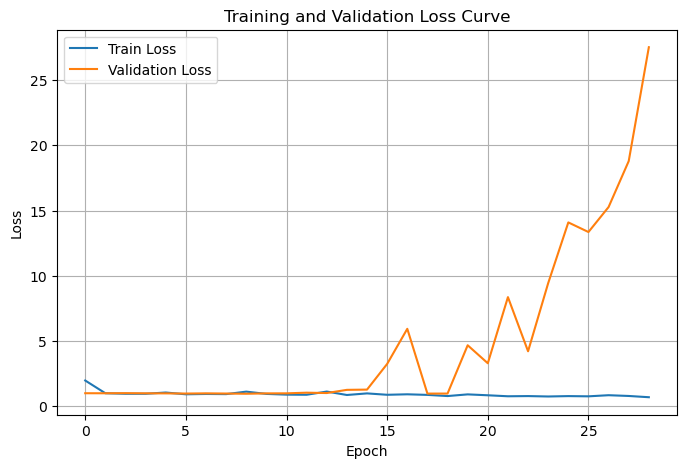

In [28]:
# 绘制训练loss曲线
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# 查看模型参数
# print(model)
from torchsummary import summary
summary(model, input_size=[(2, 500), (2, 500), (1, 500)])  # points(B, 2, N) features(B, C, N) mask(B, 1, N)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
       BatchNorm1d-1               [-1, 2, 500]               4
            Conv2d-2          [-1, 64, 500, 16]             256
       BatchNorm2d-3          [-1, 64, 500, 16]             128
              ReLU-4          [-1, 64, 500, 16]               0
            Conv2d-5          [-1, 64, 500, 16]           4,096
       BatchNorm2d-6          [-1, 64, 500, 16]             128
              ReLU-7          [-1, 64, 500, 16]               0
            Conv2d-8          [-1, 64, 500, 16]           4,096
       BatchNorm2d-9          [-1, 64, 500, 16]             128
             ReLU-10          [-1, 64, 500, 16]               0
           Conv1d-11              [-1, 64, 500]             128
      BatchNorm1d-12              [-1, 64, 500]             128
             ReLU-13              [-1, 64, 500]               0
    EdgeConvBlock-14              [-1, 

In [30]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"总参数量: {total_params:,}")
print(f"可训练参数量: {trainable_params:,}")


总参数量: 512,901
可训练参数量: 512,901


/home/server/anaconda3/envs/py310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/server/anaconda3/envs/py310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/server/anaconda3/envs/py310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/server/anaconda3/envs/py310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/server/anaconda3/envs/py310/lib/python3.10/site-packages/IPython/core/pylabtoo

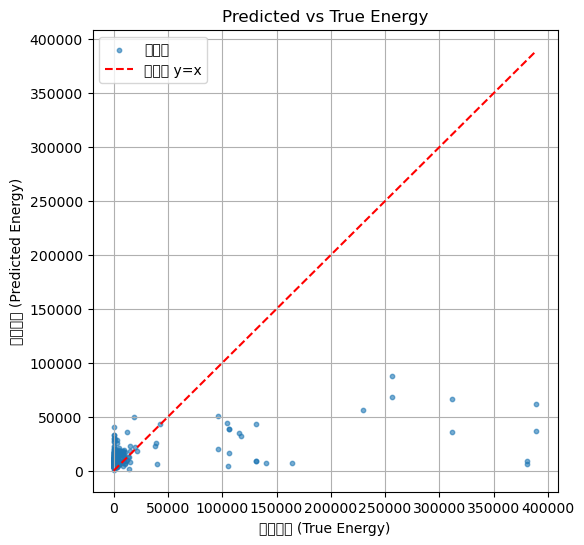

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pred_vs_true(pred, true):
    plt.figure(figsize=(6,6))
    plt.scatter(true, pred, s=10, alpha=0.6, label='预测点')
    
    # 画出 y=x 理想线
    min_val = min(np.min(true), np.min(pred))
    max_val = max(np.max(true), np.max(pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='理想线 y=x')
    
    plt.xlabel('真实能量 (True Energy)')
    plt.ylabel('预测能量 (Predicted Energy)')
    plt.title('Predicted vs True Energy')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_pred_vs_true(pred, true)



/home/server/anaconda3/envs/py310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20107 (\N{CJK UNIFIED IDEOGRAPH-4E8B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/server/anaconda3/envs/py310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20214 (\N{CJK UNIFIED IDEOGRAPH-4EF6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/server/anaconda3/envs/py310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/server/anaconda3/envs/py310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/server/anaconda3/envs/py310/lib/python3.10/site-packages/IPython/core/pylabtoo

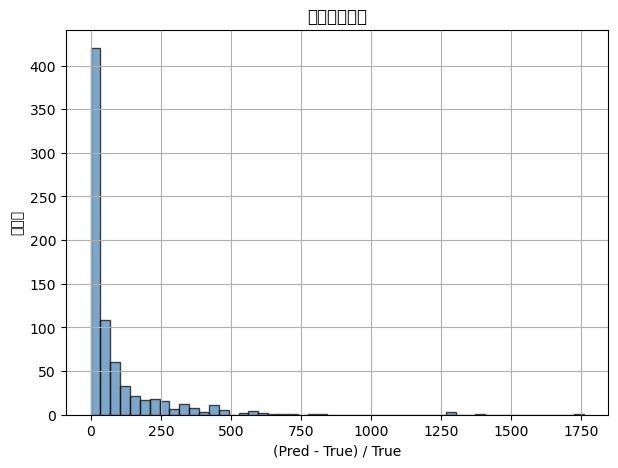

平均偏差: 88.2164
分辨率 (标准差): 166.2326


In [32]:
def plot_error_distribution(pred, true):
    rel_diff = (pred - true) / true  # 相对误差
    plt.figure(figsize=(7,5))
    plt.hist(rel_diff, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    plt.xlabel('(Pred - True) / True')
    plt.ylabel('事件数')
    plt.title('相对误差分布')
    plt.grid(True)
    plt.show()
    
    print(f"平均偏差: {np.mean(rel_diff):.4f}")
    print(f"分辨率 (标准差): {np.std(rel_diff):.4f}")
plot_error_distribution(pred, true)


/home/server/anaconda3/envs/py310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/server/anaconda3/envs/py310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/server/anaconda3/envs/py310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20559 (\N{CJK UNIFIED IDEOGRAPH-504F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/server/anaconda3/envs/py310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20381 (\N{CJK UNIFIED IDEOGRAPH-4F9D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/server/anaconda3/envs/py310/lib/python3.10/site-packages/IPython/core/pylabtoo

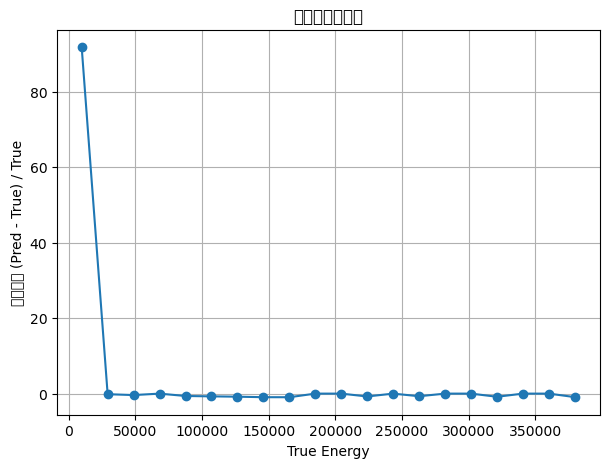

In [33]:
def plot_bias_vs_energy(pred, true, bins=20):
    rel_diff = (pred - true) / true
    bin_means, bin_edges = np.histogram(true, bins=bins, weights=rel_diff)
    bin_counts, _ = np.histogram(true, bins=bins)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    bin_avg = bin_means / np.maximum(bin_counts, 1)
    
    plt.figure(figsize=(7,5))
    plt.plot(bin_centers, bin_avg, marker='o', linestyle='-')
    plt.xlabel('True Energy')
    plt.ylabel('平均偏差 (Pred - True) / True')
    plt.title('能量依赖的偏差')
    plt.grid(True)
    plt.show()
plot_bias_vs_energy(pred, true)

### 现在加大数据量，在500个文件上进行训练！同时要注意数据预处理！

In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os
import torch.nn.functional as F
import time
import uproot
from tqdm import tqdm
import logging
import argparse
from sklearn.metrics import r2_score
from typing import Tuple, List
import copy
from multiprocessing import Pool
import psutil
import random

In [2]:

root_path = "/mnt/mydisk/WCDA_simulation/" # WCDA_simulation folder

file_path = []
for filename in os.listdir(root_path):
	full_path = os.path.join(root_path, filename)
	file_path.append(full_path)

In [ ]:
# 测试的读取数据
def print_memory(prefix=""):
    mem = psutil.Process(os.getpid()).memory_info().rss / 1024**2
    print(f"{prefix} 内存占用: {mem:.2f} MB")


# 假设 file_path 是所有文件路径的列表
num_files_to_use = 10
selected_files = file_path[:num_files_to_use]

dfs = []

for path in tqdm(selected_files, desc="Loading ROOT files"):
    try:
        with uproot.open(path) as file:
            tree = file["t_eventout;1"]
            df = tree.arrays(library="pd")
            dfs.append(df)
            print_memory("每个文件读取后")
    except Exception as e:
        print(f"⚠️ 读取文件 {path} 失败: {e}")

# 合并所有 DataFrame
data = pd.concat(dfs, ignore_index=True)
print(f"✅ 共加载 {len(data)} 个事件（来自 {len(dfs)} 个文件）")


Loading ROOT files: 100%|██████████| 10/10 [00:02<00:00,  4.16it/s]


✅ 共加载 38382 个事件（来自 10 个文件）


In [11]:
import os, psutil

print("🧩 CPU 逻辑核数:", psutil.cpu_count(logical=True))
print("💡 CPU 物理核数:", psutil.cpu_count(logical=False))
print("🚀 当前内存大小: %.2f GB" % (psutil.virtual_memory().total / 1024**3))


🧩 CPU 逻辑核数: 88
💡 CPU 物理核数: 44
🚀 当前内存大小: 220.25 GB


In [17]:
# 1. KNN 和图特征函数
def knn(x: torch.Tensor, k: int) -> torch.Tensor:
    """计算K近邻索引"""
    inner = -2 * torch.matmul(x.transpose(2, 1), x)
    xx = torch.sum(x**2, dim=1, keepdim=True)
    pairwise_distance = -xx - inner - xx.transpose(2, 1)
    return pairwise_distance.topk(k=k+1, dim=-1)[1][:, :, 1:]

def get_graph_feature(x: torch.Tensor, k: int, idx: torch.Tensor):
    """为每个点构建局部图特征"""
    B, D, N = x.size() # B是批次大小，D是特征维度，N是点的数量
    idx_base = torch.arange(0, B, device=x.device).view(-1, 1, 1) * N
    idx = (idx + idx_base).view(-1)
    
    x = x.transpose(2, 1).contiguous()
    neighbor_features = x.view(B*N, D)[idx, :].view(B, N, k, D) # 根据索引获取邻居特征，(B, N, k, D) -> (B, D, N, k)
    neighbor_features = neighbor_features.permute(0, 3, 1, 2).contiguous()
    
    x = x.permute(0, 2, 1).unsqueeze(-1).repeat(1, 1, 1, k) # copy k times x: (B, D, N, k)
    return torch.cat([x, neighbor_features - x], dim=1) # cat: (B, 2*D, N, k)

# 2. EdgeConvBlock 定义
class EdgeConvBlock(nn.Module):
    '''
    input              (B, 2, N)
    knn               -> (B, 2, N, k)
    get_graph_feature -> (B, 4, N, k)
    Edgeconv          ->(B, 4, N, k)->(B, 64, N, k)->(B, 64, N, k)->(B, 64, N, k)
    pooling           -> (B, 64, N)
     '''
    def __init__(self, k: int, in_feat: int, out_feats: Tuple[int, ...]):
        super().__init__()
        self.k = k
        self.num_layers = len(out_feats)
        
      #   # 创建卷积层
      #   self.convs = nn.ModuleList()
      #   for i in range(self.num_layers): # 每一个
      #       in_ch = 2 * in_feat if i == 0 else out_feats[i-1]
      #       self.convs.append(nn.Conv2d(in_ch, out_feats[i], kernel_size=1, bias=False)) 
        
      #   # 创建BatchNorm和激活层
      #   self.bns = nn.ModuleList()
      #   self.acts = nn.ModuleList()
      #   for i in range(self.num_layers):
      #       self.bns.append(nn.BatchNorm2d(out_feats[i])) # BN和Relu不改变维度
      #       self.acts.append(nn.ReLU(inplace=True))

        # 创建卷积层 ，BN层，激活层
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        self.acts = nn.ModuleList()
        
        for i in range(self.num_layers): #与上面写在两个循环下的写法等价
            in_ch = 2 * in_feat if i == 0 else out_feats[i-1]
            self.convs.append(nn.Conv2d(in_ch, out_feats[i], kernel_size=1, bias=False)) # 2dconv (B, 2*D, N, k) -> (B, 64, N, k)
            self.bns.append(nn.BatchNorm2d(out_feats[i])) # BN和Relu不改变维度
            self.acts.append(nn.ReLU(inplace=True))


        # 跳跃连接
        if in_feat != out_feats[-1]:
            self.sc = nn.Sequential(
                nn.Conv1d(in_feat, out_feats[-1], kernel_size=1, bias=False),
                nn.BatchNorm1d(out_feats[-1])
            )
        else:
            self.sc = None
        
        self.sc_act = nn.ReLU(inplace=True)

    def forward(self, points: torch.Tensor, features: torch.Tensor):
        # 构建KNN图
        idx = knn(points, self.k)
        # 提取图特征
        x = get_graph_feature(features, self.k, idx) # 2dconv (B, 2*D, N, k) 
        
        # 多层卷积处理，每个edgeconv下进行3次卷积是为了增强非线性表达能力（因为有多次的激活函数）
        for i in range(self.num_layers): # (B, 64, N, k) -> (B, 64, N, k) -> (B, 64, N, k) 
            x = self.convs[i](x)  
            x = self.bns[i](x)
            x = self.acts[i](x)
        
        # 池化: 对k维度求平均
        fts = x.mean(dim=-1) # (B, 64, N, k) -> (B, 64, N)
        
        # 跳跃连接
        sc = self.sc(features) if self.sc else features
        return self.sc_act(sc + fts)


In [35]:
# 截取前一百个尝试
file_path = file_path[:100]
print(len(file_path))

100


In [18]:
def process_features(features, processing_conditions):
    features = np.array(features, dtype=np.float32)
    for i, cond in enumerate(processing_conditions):
        #features[:, i] = (features[:, i] - cond.get('subtract', 0)) * cond.get('multiply', 1)
        #features[:, i] = np.clip(features[:, i], cond.get('min', -5), cond.get('max', 5))
        col = features[:, i].copy()
        
        # 对坐标特征（vx, vy）仅做线性变换，不做截断和标准化
        if i < 2:  # 前两列为坐标
            col = (col - cond['subtract']) * cond['multiply']
        else:
            # 其他特征：线性变换 + 截断 + 标准化
            col = (col - cond['subtract']) * cond['multiply']
            col = np.clip(col, cond['min'], cond['max'])
            #col = (col - np.mean(col)) / (np.std(col) + 1e-8)
        
        features[:, i] = col
    return features

In [19]:
class ParticleDataset(Dataset):
    '''
    Dateset 需要做到
    - ✅并行加载root文件
    - ✅提取branch[vx vy vt vq]和target_branch[mc_energy]
    - ✅根据process_conditions 处理数据,主要是为了剔除离群值
    - ✅由于每个event的hit数不一样，需要填充/随机采样数据到max_points
    - 对点云做去中心化处理(vx, vy) - (xc, yc)
    - 对数据进行标准化，(vq, vt)需要标准化,全局标准化? 还是逐事例的标准化！
    - ✅对能量标签取log，但是不做标准化
    
    input:
    - root_files:    文件根目录，文件名列表
    - branch:        需要读取的特征[vx vy vt vq]
    - target_branch: 标签[mc_energy]
    - processing_conditions:预处理条件
    - max_points:     固定的数据长度
    
    return
    - points:     去中心化之后的点云的二维坐标(vx-xc, vy-yc)
    - features:   预处理和归一化后的点云特征(vq, vt)
    - mask:       padding和截断造成的mask
    - log_energy: 预处理和log之后的真实能量 mc_energy
    '''
    def __init__(self, root_files, branches, target_branch, processing_conditions, max_points=256):
        self.branches = branches
        self.target_branch = target_branch
        self.processing_conditions = processing_conditions
        self.max_points = max_points

        # 并行加载 ROOT 文件
        with Pool(min(4, os.cpu_count())) as pool:
            self.data = pool.starmap(
                self._load_file,
                [(f, branches, target_branch, processing_conditions) for f in root_files]
            )

        # 展平所有文件的数据
        self.data = [item for sublist in self.data for item in sublist]
        self.indices = torch.randperm(len(self.data)).tolist()
        print(f"✅ Loaded {len(self.data)} events from {len(root_files)} files")

    @staticmethod
    def _load_file(file_path, branches, target_branch, processing_conditions):
        """从单个ROOT文件中提取数据"""
        try:
            with uproot.open(file_path) as f:
                tree = f["t_eventout;1"]
                # 读取 vx, vy, vt, vq + xc, yc + mc_energy
                arrays = tree.arrays(branches + target_branch + ["xc", "yc"], library="np")

                n_events = len(next(iter(arrays.values())))
                results = []

                for i in range(n_events): # 对每个event
                    # (1) 原始特征矩阵
                    features = np.column_stack([arrays[b][i] for b in branches])
                    features = process_features(features, processing_conditions)  # 剔除离群值

                    # (2) 点云中心化: (vx, vy) - (xc, yc)
                    vx, vy = features[:, 0], features[:, 1]
                    xc, yc = arrays["xc"][i], arrays["yc"][i]
                    points = np.column_stack([vx - xc, vy - yc])

                    # (3) 对 (vq, vt) 做标准化（列 2,3）注意vt和vq顺序
                    vq = features[:, 3]
                    vt = features[:, 2]
                    vq = (vq - np.mean(vq)) / (np.std(vq) + 1e-8) # 逐事例的标准化
                    vt = (vt - np.mean(vt)) / (np.std(vt) + 1e-8)
                    norm_features = np.column_stack([vq, vt])

                    # (4) 能量标签取 log10
                    target = arrays["mc_energy"][i]
                    log_energy = np.log10(target) if target > 0 else 0.0

                    results.append((points, norm_features, log_energy))

                return results

        except Exception as e:
            print(f"⚠️ 文件 {file_path} 读取失败: {e}")
            return []

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        points, features, log_energy = self.data[real_idx]

        n_points = len(points)

        # padding 或随机采样
        if n_points > self.max_points:
            idxs = np.random.choice(n_points, self.max_points, replace=False)
            points = points[idxs]
            features = features[idxs]
            mask = np.ones(self.max_points)
        else:
            pad_len = self.max_points - n_points
            pad_points = np.zeros((pad_len, 2))
            pad_features = np.zeros((pad_len, features.shape[1]))
            points = np.vstack([points, pad_points])
            features = np.vstack([features, pad_features]) # 这里的features已经是load-file输出的norm_features了
            mask = np.concatenate([np.ones(n_points), np.zeros(pad_len)])
         
        points = torch.tensor(points, dtype=torch.float32).T # 转置维度: (N, 2) → (2, N)
        features = torch.tensor(features, dtype=torch.float32).T # 转置维度: (N, 2) → (2, N)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0) # 修复mask的维度(B, N) -> (B, 1, N)
        log_energy = torch.tensor(log_energy, dtype=torch.float32).unsqueeze(-1) # [B, 1]
        
        return points, features, mask, log_energy
        




In [88]:
# 测试Dataset
import torch
from torch.utils.data import DataLoader

# ✅ 选择少量文件测试（1~2个足够）
test_files = file_path[:100]

# ✅ 特征处理配置
processing_conditions = [
    {"name": "vx", "subtract": 0, "multiply": 1, "min": -1e5, "max": 1e5},
    {"name": "vy", "subtract": 0, "multiply": 1, "min": -1e5, "max": 1e5},
    {"name": "vt", "subtract": 0, "multiply": 1, "min": -1e5, "max": 1e5},
    {"name": "vq", "subtract": 0, "multiply": 1, "min": -1e5, "max": 1e5},
]

branches = [d["name"] for d in processing_conditions]
target_branch = ["mc_energy"]

# 删除掉 name 字段，得到纯预处理配置
processing_conditions = [
    {k: v for k, v in d.items() if k != "name"} for d in processing_conditions
]

# ✅ 实例化数据集
dataset = ParticleDataset(test_files, branches, target_branch, processing_conditions)

# ✅ 创建 DataLoader
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# ✅ 查看一个样本
points, features, mask, log_energy = next(iter(loader))

print("\n=== 样本检查 ===")
print(f"points shape: {points.shape}")      # [batch, 2, N]
print(f"features shape: {features.shape}")  # [batch, 2, N]
print(f"mask shape: {mask.shape}")          # [batch, 1, N]
print(f"log_energy shape: {log_energy.shape}")  # [batch]

# ===== 计算特征统计 =====
# 这里 dim=(0, 2)：跨 batch 和 num_points 两个维度求均值、方差，只保留每个特征通道的结果
feat_mean = features.mean(dim=(0, 2))
feat_std = features.std(dim=(0, 2))
print(f"feature mean per-dim: {feat_mean}")
print(f"feature std per-dim: {feat_std}")

# ===== 计算点云坐标统计 =====
point_mean = points.mean(dim=(0, 2))
point_std = points.std(dim=(0, 2))
print(f"points mean per-dim: {point_mean}")
print(f"points std per-dim: {point_std}")

# ===== 其他信息 =====
print(f"features overall mean: {features.mean():.4f}, std: {features.std():.4f}")
print(f"是否含NaN: {torch.isnan(features).any().item()}")


✅ Loaded 385602 events from 100 files

=== 样本检查 ===
points shape: torch.Size([32, 2, 256])
features shape: torch.Size([32, 2, 256])
mask shape: torch.Size([32, 1, 256])
log_energy shape: torch.Size([32, 1])
feature mean per-dim: tensor([-0.0003,  0.0038])
feature std per-dim: tensor([0.6362, 0.6666])
points mean per-dim: tensor([10.0031, -1.7485])
points std per-dim: tensor([86.2840, 73.6893])
features overall mean: 0.0018, std: 0.6516
是否含NaN: False


ParticleNetRegressor 模型框架 


                         ┌──────────────────────────────────────────────────┐
                         │                ParticleNetRegressor              │
                         └──────────────────────────────────────────────────┘
                                        │
                                        │ Input: (B, N, 2+2)
                                        │        points: [vx, vy]
                                        │        features: [vq, vt]
                                        │        mask: 有效击中点掩码
                                        ▼
                      ┌───────────────────────────────────────────┐
                      │   特征归一化层 (BatchNorm1d)              │
                      │   对输入特征(vq, vt)按通道归一化          │
                      └───────────────────────────────────────────┘
                                        │
                                        ▼
                          ┌────────────────────────────┐
                          │  EdgeConv Block × 3 层     │
                          │  每层包含：                 │
                          │   - KNN图构建(k=16)        │
                          │   - 特征信息聚合(MLP)      │
                          │   - 输出通道：64→128→256   │
                          └────────────────────────────┘
                                        │
                          ┌────────────────────────────┐
                          │   特征融合 (Fusion Block)  │
                          │   将多层EdgeConv输出拼接   │
                          │   (64+128+256 → 256通道)   │
                          │   1×1卷积 + BN + ReLU      │
                          └────────────────────────────┘
                                        │
                          ┌────────────────────────────┐
                          │   全局池化 (Global AvgPool)│
                          │   对有效mask求平均 (B,256) │
                          └────────────────────────────┘
                                        │
                          ┌────────────────────────────┐
                          │   全连接层回归头 (FCs)    │
                          │   [256→256→128→1]         │
                          │   ReLU + Dropout(0.1)      │
                          └────────────────────────────┘
                                        │
                                        ▼
                             输出: log(能量预测) (B,1)


In [10]:
class ParticleNetRegressor(nn.Module):
    '''
    主要网络
    input 
    - points(B, 2, N) features(B, C, N) mask(B, 1, N)
    
    model:
    EdgeConv block *3
    fusion block
    Global avgPool
    FCs
    
    output:
    pred_log_energy
    '''
    def __init__(self, input_dims: int, 
                 conv_params: List[Tuple[int, Tuple[int, ...]]] = [(16, (64, 64, 64)), (16, (128, 128, 128)), (16, (256, 256, 256))],
                 fc_params: List[Tuple[int, float]] = [(256, 0.1), (128, 0.1)],
                 use_fusion: bool = True):
        super().__init__()
        self.use_fusion = use_fusion

        # 输入特征批归一化 input_dims=2 (vq, vt)
        self.bn_fts = nn.BatchNorm1d(input_dims)
        
        # EdgeConv 块
        self.edge_convs = nn.ModuleList()
        for idx, (k, channels) in enumerate(conv_params):  # (B, 2, N, k) -> (B, 64, N, k) -> (B, 128, N, k) -> (B, 256, N, k) 
            in_feat = input_dims if idx == 0 else conv_params[idx-1][1][-1]
            self.edge_convs.append(EdgeConvBlock(k, in_feat, channels))
        
        # 特征融合
        if use_fusion:
            fusion_in = sum(x[1][-1] for x in conv_params)
            self.fusion_block = nn.Sequential(
                nn.Conv1d(fusion_in, 256, kernel_size=1, bias=False),
                nn.BatchNorm1d(256),
                nn.ReLU()
            )
            fc_input_dim = 256
        else:
            fc_input_dim = conv_params[-1][1][-1]
        
        # 回归头(全连接层）
        fcs = []
        for idx, (out_dim, dropout) in enumerate(fc_params):
            in_dim = fc_input_dim if idx == 0 else fc_params[idx-1][0]
            fcs.extend([
                nn.Linear(in_dim, out_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
        # 输出层 - 回归任务输出1个值（能量）
        fcs.append(nn.Linear(fc_params[-1][0], 1))
        self.fc = nn.Sequential(*fcs)
        
        # 权重初始化
        for m in self.modules():
            if isinstance(m, (nn.Conv1d, nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None: 
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, points: torch.Tensor, features: torch.Tensor, mask: torch.Tensor):
        """
        前向传播
        输入:
            points: (B, 2, N) - 坐标 [x, y]
            features: (B, 2, N) - 特征 [电荷, 时间]
            mask: (B, 1, N) - 掩码
        输出:
            energy: (B, 1) - 预测能量
        """
        if mask.dim() == 2:  # 防止mask是(B, N)
            print("mask维度有问题")
            mask = mask.unsqueeze(1)
        # 应用掩码
        points = points * mask
        features = features * mask
        coord_shift = (mask == 0) * 1e9  # 填充点坐标加1e9，使其在KNN中被忽略
        
        # 特征归一化
        fts = self.bn_fts(features) * mask
        outputs = []
        
        # 多层EdgeConv
        for idx, conv in enumerate(self.edge_convs):
            # 第一层用坐标构建图，后续用特征
            pts = (points if idx == 0 else fts) + coord_shift # 坐标加上偏移
            fts = conv(pts, fts) * mask
            # pts: (B, 2, N) - 用于构建KNN图
				# fts: (B, 2, N) -> (B, 64, N) -> (B, 128, N)  -> (B, 256, N) - 三层卷积层，特征维度提升
            if self.use_fusion:
                outputs.append(fts)
        
        # 拼接三个层次的输出, 特征融合
        if self.use_fusion:
            fts = self.fusion_block(torch.cat(outputs, dim=1)) * mask # (B, 64+128+256, N) -> (B, 256, N)
        
        # 全局平均池化 - 只对有效点求平均
        x = fts.sum(dim=-1) / mask.float().sum(dim=-1).clamp(min=1) # (B, 256, N) -> 输出: (B, 256)
        
        # 回归预测
        energy = self.fc(x) # (B, 256) -> (B, 256) -> (B, 128) -> (B, 1)
        return energy

In [11]:
def train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=100,
    lr=1e-3,
    patience=20,
    min_delta=1e-4,
    grad_clip=5.0,  # 新增梯度裁剪，防止梯度爆炸
    save_path="best_model_2.pt"  # 自动保存模型,best_model.pt是用500个文件训练的数据
):
    """
    ParticleNet 训练函数（带早停、学习率调度、梯度裁剪）
    """

    # ---------- 初始化 ----------
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🖥️ 使用设备: {device}")

    if torch.cuda.device_count() > 1:
        print(f"🔸 使用 {torch.cuda.device_count()} 个GPU")
        model = nn.DataParallel(model)

    model.to(device)

    # ---------- 优化器 & 调度器 ----------
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=10, factor=0.5, verbose=True
    )

    train_losses, val_losses = [], []

    # ---------- Early Stopping ----------
    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    # ---------- 训练循环 ----------
    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss = 0.0

        # 使用 tqdm 进度条更直观（可选）
        pbar = enumerate(train_loader)
        # from tqdm import tqdm
        # pbar = tqdm(enumerate(train_loader), total=len(train_loader))

        for batch_idx, (points, features, mask, energies) in pbar:
            points, features, mask, energies = (
                points.to(device),
                features.to(device),
                mask.to(device),
                energies.to(device),
            )

            optimizer.zero_grad(set_to_none=True)  # 更高效的梯度清零方式
            preds = model(points, features, mask)
            loss = criterion(preds, energies)
            loss.backward()

            # 梯度裁剪：控制梯度爆炸
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()
            train_loss += loss.item()

            if batch_idx % 200 == 0:# 打印每个epoch里的进度
                print(
                    f"Epoch[{epoch}/{num_epochs}] Batch[{batch_idx}/{len(train_loader)}] "
                    f"TrainLoss: {loss.item():.6f}"
                )

        # ---------- 验证阶段 ----------
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for points, features, mask, energies in val_loader:
                points, features, mask, energies = (
                    points.to(device),
                    features.to(device),
                    mask.to(device),
                    energies.to(device),
                )
                preds = model(points, features, mask)
                val_loss += criterion(preds, energies).item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        scheduler.step(val_loss)  # 更新学习率
        lr_now = optimizer.param_groups[0]["lr"]

        print(
            f"📘 Epoch {epoch:03d}/{num_epochs} | "
            f"Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {lr_now:.6e}"
        )

        # ---------- Early Stopping ----------
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            torch.save(best_model_wts, save_path)
            print(f"✅ Val loss improved to {val_loss:.6f}, model saved to '{save_path}'")
        else:
            epochs_no_improve += 1
            print(f"⚠️ No improvement ({epochs_no_improve}/{patience})")

        if epochs_no_improve >= patience:
            print(f"⏹️ Early stopping triggered at epoch {epoch}.")
            break

    # ---------- 恢复最佳模型 ----------
    model.load_state_dict(best_model_wts)
    print(f"🏁 Training completed. Best Val Loss: {best_val_loss:.6f}")
    return train_losses, val_losses


In [ ]:
def evaluate_model(model, test_loader):
    """
    评估模型性能（针对 log(E) 回归任务）
    
    模型输出和标签均为 log(E)，评估时自动反 log。
    计算:
        - 能量分辨率 σ = std((E_pred - E_true)/E_true)
        - 能量偏差 bias = mean((E_pred - E_true)/E_true)
        - R² 分数
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()
    
    predictions = []
    true_energies = []
    
    with torch.no_grad():
        for points, features, mask, logE_true in test_loader:
            # 移动到设备
            points = points.to(device)
            features = features.to(device)
            mask = mask.to(device)
            logE_true = logE_true.to(device)

            # 预测 log(E)
            logE_pred = model(points, features, mask)

            # 转为 NumPy 并反 log
            E_pred = torch.exp(logE_pred).cpu().numpy().flatten()
            E_true = torch.exp(logE_true).cpu().numpy().flatten()

            predictions.extend(E_pred)
            true_energies.extend(E_true)
    
    predictions = np.array(predictions)
    true_energies = np.array(true_energies)

    if len(predictions) == 0:
        print("❌ 没有预测结果")
        return None, None

    # ===== 计算指标 =====
    rel_error = (predictions - true_energies) / true_energies
    resolution = np.std(rel_error)       # 能量分辨率 越低越好
    bias = np.mean(rel_error)            # 平均偏差
    r2 = r2_score(true_energies, predictions)  # R² 评分

    print("=== 模型评估结果 ===")
    print(f"能量分辨率 (σ): {resolution:.4f}")
    print(f"能量偏差 (bias): {bias:.4f}")
    print(f"R² Score: {r2:.4f}")

    return predictions, true_energies # 返回的是真实能量


In [93]:
def check_gpu_status():
    """检查GPU状态"""
    print("=" * 50)
    print("GPU状态检查")
    print("=" * 50)
    
    # 检查CUDA是否可用
    print(f"CUDA可用: {torch.cuda.is_available()}")
    
    if torch.cuda.is_available():
        # 检查GPU数量
        print(f"GPU数量: {torch.cuda.device_count()}")
        
        # 检查每个GPU的状态
        for i in range(torch.cuda.device_count()):
            print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
            print(f"  内存分配: {torch.cuda.memory_allocated(i) / 1024**3:.2f} GB")
            print(f"  内存缓存: {torch.cuda.memory_reserved(i) / 1024**3:.2f} GB")
        
        # 检查当前设备
        print(f"当前设备: {torch.cuda.current_device()}")
        print(f"CUDA版本: {torch.version.cuda}")
    else:
        print("❌ 没有检测到可用的GPU")
    
    print("=" * 50)


In [ ]:
def main():
    '''
    - 读取数据文件夹列表root_files
    - 提供预处理条件branches, target_branch, processing_conditions
    - 检查GPU状态
    - 划分数据集（从文件层面）
    - 创建数据集dataset, 分批读root_files, branches, target_branch, processing_conditions, max_points=256
    - 加载数据dataloader
    - model initial
    - device to cuda
    - test 一个迭代器
    - train函数
    - evaluate函数
    - return model, predictions, true_energies, train_losses, val_losses
     '''
   
	 # ======== 读取数据文件夹 ========
    root_path = "/mnt/mydisk/WCDA_simulation/" # WCDA_simulation folder
    file_path = []
    for filename in os.listdir(root_path):
           full_path = os.path.join(root_path, filename)
           file_path.append(full_path)
    
	 # 只提取前100个进行训练
    root_files = file_path[:500] 
    print(f"📁 本次使用 {len(root_files)} 个ROOT文件数据")

	 # ======== 预处理条件 ========       
    processing_conditions = [
            {"name": "vx",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0},
            {"name": "vy",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0},  
            {"name": "vt",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0},
            {"name": "vq",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0}
        ]
    branches = [d["name"] for d in processing_conditions] # 提取name列表，便于后续读取相关的值 ，输入特征
    target_branch = ["mc_energy"] # 定义一个标签列表， 预测目标是能量
    processing_conditions = [
        {k: v for k, v in d.items() if k != "name"} # 删除掉name字段，只保留预处理操作字段
        for d in processing_conditions
    ]
    
    # ======== 先检查GPU状态 ========
    check_gpu_status()
    
    # ======== 从文件层面划分数据集 =======
    from sklearn.model_selection import train_test_split
    
    # 分割数据
    train_files, test_files = train_test_split(root_files, test_size=0.2, random_state=42)
    train_files, val_files = train_test_split(train_files, test_size=0.1, random_state=42)
    
	# train_model 使用数据train 2728 和 val 304
   # evaluate_model使用数据 test 758
    print(f"训练集文件数: {len(train_files)}") # 72%
    print(f"验证集文件数: {len(val_files)}")   # 8%
    print(f"测试集文件数: {len(test_files)}")  # 20%
    
    # ======== 构建数据集 ========
    train_dataset = ParticleDataset(
        root_files=train_files,
        branches=branches,
        target_branch=target_branch,
        processing_conditions=processing_conditions,
        max_points=256
    )
    
    val_dataset = ParticleDataset(
        root_files=val_files,
        branches=branches,
        target_branch=target_branch,
        processing_conditions=processing_conditions,
        max_points=256
    )

    test_dataset = ParticleDataset(
        root_files=test_files,
        branches=branches,
        target_branch=target_branch,
        processing_conditions=processing_conditions,
        max_points=256
    )
    
    # ======== 构建 DataLoader ========
    batch_size = 512
    print(f"Batch Size: {batch_size}")
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # ======== 初始化模型 ========
    model = ParticleNetRegressor(
        input_dims=2,  # vq, vt 两个特征
        conv_params=[(16, (64, 64, 64)), (16, (128, 128, 128)), (16, (256, 256, 256))],
        fc_params=[(256, 0.1), (128, 0.1)],
        use_fusion=True
    )
    
    # 立即将模型移动到GPU进行测试
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    print(f"模型已移动到: {device}")
    
    # ======== 测试一次前向传播，确保模型正常 ========
    print("测试GPU运行...")
    with torch.no_grad():
        test_points, test_features, test_mask, test_energies = next(iter(train_loader))
        test_points = test_points.to(device)
        test_features = test_features.to(device)
        test_mask = test_mask.to(device)
        output = model(test_points, test_features, test_mask)
        print(f"测试输出形状: {output.shape}") # 应该输出(batch_size, 1)
        # print(output)
        print(f"测试输出值范围: {output.min().item():.4f} ~ {output.max().item():.4f}") # log_energy


    # ======== 训练模型 ========
    print("开始训练...")
    train_losses, val_losses = train_model(model, train_loader, val_loader, num_epochs=500)
    
    # ======== 评估模型 ========
    print("评估模型...")
   #  model.load_state_dict(torch.load("best_model.pt")) #不需要重新train，直接evaluate
   #  model.eval()
    log_pred, log_energies = evaluate_model(model, test_loader) 
    
    return model, log_pred, log_energies, train_losses, val_losses
   

In [ ]:
# 运行
if __name__ == "__main__":
	model, pred, true, train_losses, val_losses = main()

📁 本次使用 500 个ROOT文件数据
GPU状态检查
CUDA可用: True
GPU数量: 4
GPU 0: Tesla V100-SXM2-16GB
  内存分配: 0.03 GB
  内存缓存: 2.26 GB
GPU 1: Tesla V100-SXM2-16GB
  内存分配: 0.02 GB
  内存缓存: 2.10 GB
GPU 2: Tesla V100-SXM2-16GB
  内存分配: 0.02 GB
  内存缓存: 2.10 GB
GPU 3: Tesla V100-SXM2-16GB
  内存分配: 0.02 GB
  内存缓存: 2.10 GB
当前设备: 0
CUDA版本: 12.4
训练集文件数: 360
验证集文件数: 40
测试集文件数: 100
✅ Loaded 1385551 events from 360 files
✅ Loaded 154214 events from 40 files
✅ Loaded 385420 events from 100 files
Batch Size: 512
模型已移动到: cuda
测试GPU运行...
测试输出形状: torch.Size([512, 1])
测试输出值范围: -2.2278 ~ 0.4662
开始训练...
🖥️ 使用设备: cuda
🔸 使用 4 个GPU
Epoch[1/500] Batch[0/2707] TrainLoss: 10.567118
Epoch[1/500] Batch[200/2707] TrainLoss: 0.488228
Epoch[1/500] Batch[400/2707] TrainLoss: 0.519303
Epoch[1/500] Batch[600/2707] TrainLoss: 0.491682
Epoch[1/500] Batch[800/2707] TrainLoss: 0.485741
Epoch[1/500] Batch[1000/2707] TrainLoss: 0.465379
Epoch[1/500] Batch[1200/2707] TrainLoss: 0.505173
Epoch[1/500] Batch[1400/2707] TrainLoss: 0.455781
Epoch[1/500] Bat

500files结果：
评估模型...
=== 模型评估结果 ===
能量分辨率 (σ): 0.8685   表示预测与真值相对误差的标准差约为 87% —— 即样本间典型误差非常大（接近一倍）。对大多数能量重建任务来说这是偏大的，说明模型预测波动很大
能量偏差 (bias): 0.2006
R² Score: 0.6126

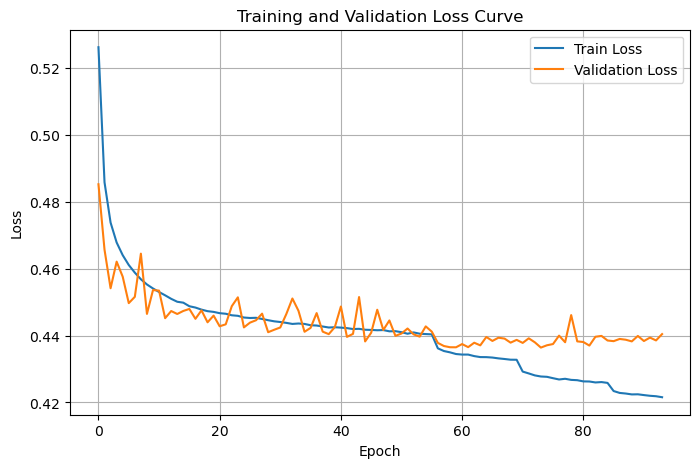

In [97]:
# 绘制训练loss曲线
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

📁 本次随机选取使用 100 个ROOT文件数据进行评估
✅ Loaded 384851 events from 100 files
评估模型...
使用设备: cuda
⚙️ 检测到 DataParallel 模型，已移除 'module.' 前缀
✅ 成功加载模型权重: best_model_2.pt


/tmp/ipykernel_3637919/2113838656.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)



=== 模型评估结果 ===
能量分辨率 (σ): 1.3415
能量偏差 (bias): -0.5650
R² Score: -5.8136


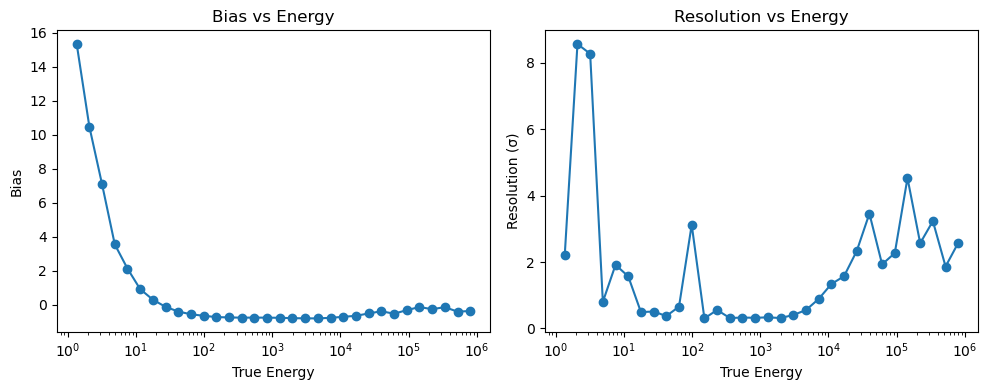

In [16]:
# 直接加载best_model_2进行评估，不需要进行训练
def evaluate(model, test_loader, checkpoint_path="best_model.pt"):
    """
    评估 ParticleNet 模型性能（针对 log(E) 回归任务）
    
    模型输出和标签均为 log(E)，评估时自动反 log。
    输出指标：
        - 能量分辨率 σ = std((E_pred - E_true)/E_true)
        - 能量偏差 bias = mean((E_pred - E_true)/E_true)
        - R² 分数
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"使用设备: {device}")

    # === 加载保存的模型参数 ===
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # 兼容 DataParallel 保存的权重 在多GPU上训练，在单GPU上评估时遇到
    if any(k.startswith("module.") for k in checkpoint.keys()):
        checkpoint = {k.replace("module.", ""): v for k, v in checkpoint.items()}
        print("⚙️ 检测到 DataParallel 模型，已移除 'module.' 前缀")
        
    model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()
    print(f"✅ 成功加载模型权重: {checkpoint_path}")

    predictions = []
    true_energies = []

    with torch.no_grad():
        for points, features, mask, logE_true in test_loader:
            points = points.to(device)
            features = features.to(device)
            mask = mask.to(device)
            logE_true = logE_true.to(device)

            # 模型预测 log(E)
            logE_pred = model(points, features, mask)

            # 反 log 得到能量
            E_pred = torch.pow(10, logE_pred).cpu().numpy().flatten()
            E_true = torch.pow(10, logE_true).cpu().numpy().flatten()

            predictions.extend(E_pred)
            true_energies.extend(E_true)

    predictions = np.array(predictions)
    true_energies = np.array(true_energies)

    # ===== 计算性能指标 =====
    if len(predictions) == 0:
        print("❌ 没有预测结果")
        return None, None

    rel_error = (predictions - true_energies) / true_energies
    resolution = np.std(rel_error)
    bias = np.mean(rel_error)
    r2 = r2_score(true_energies, predictions)

    print("\n=== 模型评估结果 ===")
    print(f"能量分辨率 (σ): {resolution:.4f}")
    print(f"能量偏差 (bias): {bias:.4f}")
    print(f"R² Score: {r2:.4f}")

    return predictions, true_energies


#  画图函数
def plot_bias_resolution(true_E, pred_E, bins=32):
    true_E = np.array(true_E)
    pred_E = np.array(pred_E)

    bin_edges = np.logspace(np.log10(true_E.min()), np.log10(true_E.max()), bins+1)
    bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])

    bias, resolution = [], []
    for i in range(bins):
        mask = (true_E >= bin_edges[i]) & (true_E < bin_edges[i+1])
        if mask.sum() > 10:
            rel = (pred_E[mask] - true_E[mask]) / true_E[mask]
            bias.append(np.mean(rel))
            resolution.append(np.std(rel))
        else:
            bias.append(np.nan)
            resolution.append(np.nan)

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].plot(bin_centers, bias, 'o-')
    ax[0].set_xscale('log')
    ax[0].set_xlabel("True Energy")
    ax[0].set_ylabel("Bias")
    ax[0].set_title("Bias vs Energy")

    ax[1].plot(bin_centers, resolution, 'o-')
    ax[1].set_xscale('log')
    ax[1].set_xlabel("True Energy")
    ax[1].set_ylabel("Resolution (σ)")
    ax[1].set_title("Resolution vs Energy")

    plt.tight_layout()
    plt.show()

import random
# 主函数
def main():
    '''
    加载保存的model进行评估的主函数
     '''
   
	 # ======== 读取数据文件夹 ========
    root_path = "/mnt/mydisk/WCDA_simulation/" # WCDA_simulation folder
    file_path = []
    for filename in os.listdir(root_path):
           full_path = os.path.join(root_path, filename)
           file_path.append(full_path)
    
	 # 随机提取100个进行评估
    test_files = random.sample(file_path, 100) # 500*20%
    print(f"📁 本次随机选取使用 {len(test_files)} 个ROOT文件数据进行评估")

	 # ======== 预处理条件 ========       
    processing_conditions = [
            {"name": "vx",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0},
            {"name": "vy",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0},  
            {"name": "vt",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0},
            {"name": "vq",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0}
        ]
    branches = [d["name"] for d in processing_conditions] # 提取name列表，便于后续读取相关的值 ，输入特征
    target_branch = ["mc_energy"] # 定义一个标签列表， 预测目标是能量
    processing_conditions = [
        {k: v for k, v in d.items() if k != "name"} # 删除掉name字段，只保留预处理操作字段
        for d in processing_conditions
    ]
    
   #  # ======== 先检查GPU状态 ========
   #  check_gpu_status()
   
    # 只构建test数据集
    batch_size = 512  
    test_dataset = ParticleDataset(
        root_files=test_files,
        branches=branches,
        target_branch=target_branch,
        processing_conditions=processing_conditions,
        max_points=256
    )
    
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # ======== 初始化模型 ========
    model = ParticleNetRegressor(
        input_dims=2,  # vq, vt 两个特征
        conv_params=[(24, (64, 64, 64)), (16, (128, 128, 128)), (16, (256, 256, 256))],
        fc_params=[(256, 0.1), (128, 0.1)],
        use_fusion=True
    )
    
    # ======== 评估模型 ========
    print("评估模型...")
   #  model.load_state_dict(torch.load("best_model.pt")) #不需要重新train，直接evaluate
   #  model.eval()
    pred, energies = evaluate(model, test_loader, checkpoint_path="best_model_2.pt")
    
    plot_bias_resolution(energies, pred)
    return pred, energies
   

if __name__ == "__main__":
    pred, true = main() # 返回的是E，不是logE



In [17]:
# 查看模型参数
# print(model)
from torchsummary import summary
summary(model, input_size=[(2, 500), (2, 500), (1, 500)])  # points(B, 2, N) features(B, C, N) mask(B, 1, N)

NameError: name 'model' is not defined

In [99]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"总参数量: {total_params:,}")
print(f"可训练参数量: {trainable_params:,}")


总参数量: 512,901
可训练参数量: 512,901


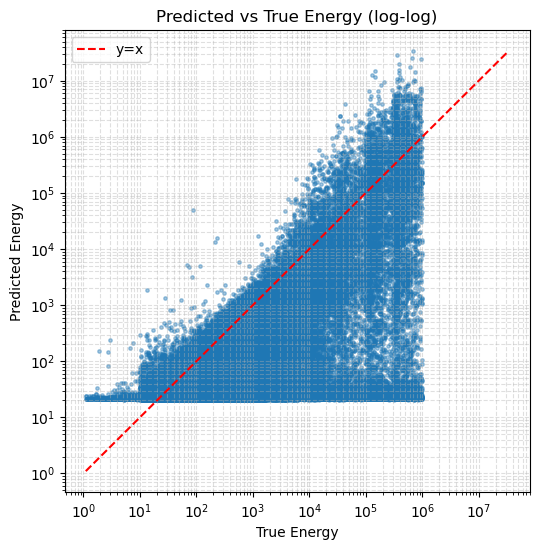

In [18]:
# 基本散点图（log-log）与 1:1 线
import matplotlib.pyplot as plt

# predictions, true_energies 为 evaluate 返回的 numpy 数组（真实能量）
plt.figure(figsize=(6,6))
plt.scatter(true, pred, s=6, alpha=0.4)
mn = min(true.min(), pred.min())
mx = max(true.max(), pred.max())
plt.plot([mn, mx], [mn, mx], 'r--', label='y=x')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('True Energy'); plt.ylabel('Predicted Energy')
plt.legend(); plt.grid(True, which='both', ls='--', alpha=0.4)
plt.title('Predicted vs True Energy (log-log)')
plt.show()


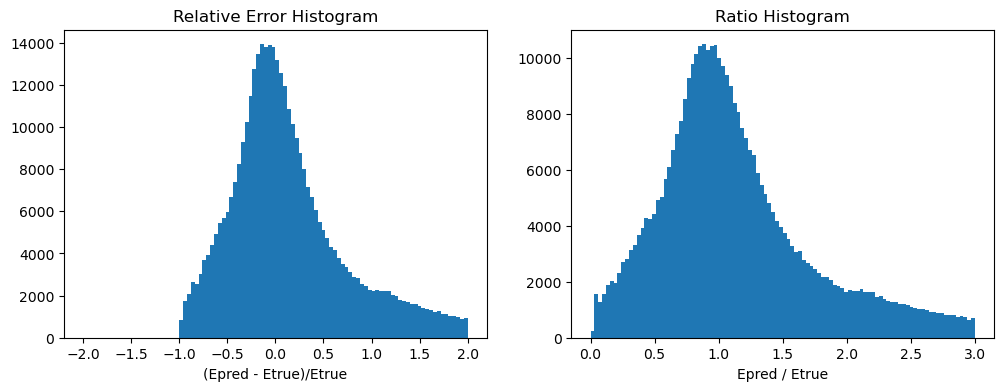

In [ ]:
# 残差分布与 E_pred/E_true 比值直方图
rel = (pred - true) / true
ratio = pred / true

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(rel, bins=100, range=(-2,2))
plt.xlabel('(Epred - Etrue)/Etrue'); plt.title('Relative Error Histogram')

plt.subplot(1,2,2)
plt.hist(ratio, bins=100, range=(0,3))
plt.xlabel('Epred / Etrue'); plt.title('Ratio Histogram')
plt.show()


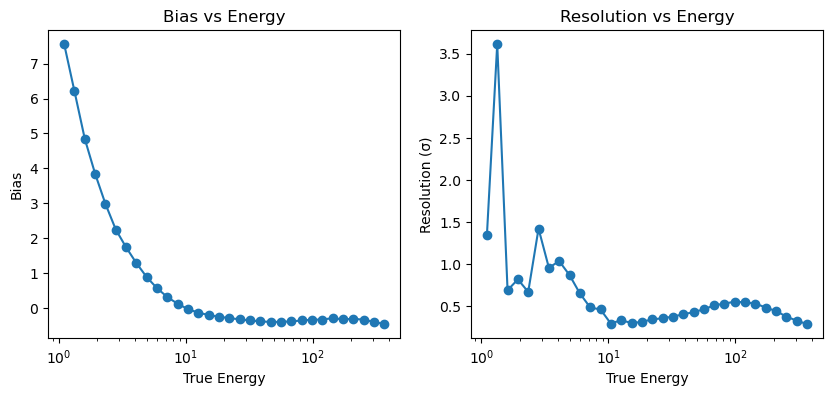

In [ ]:
# bias / resolution 分能量区间统计
def binned_stats(true, pred, nbins=8):
    bins = np.logspace(np.log10(true.min()), np.log10(true.max()), nbins+1)
    bin_centers, bias_list, res_list, count_list = [], [], [], []
    for i in range(nbins):
        mask = (true >= bins[i]) & (true < bins[i+1])
        if mask.sum() == 0: continue
        t = true[mask]; p = pred[mask]
        rel = (p - t) / t
        bin_centers.append(np.sqrt(bins[i]*bins[i+1]))
        bias_list.append(np.mean(rel))
        res_list.append(np.std(rel))
        count_list.append(mask.sum())
    return np.array(bin_centers), np.array(bias_list), np.array(res_list), np.array(count_list)

centers, bias_b, res_b, counts = binned_stats(true, pred, nbins=32)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.errorbar(centers, bias_b, yerr=None, fmt='o-')
plt.xscale('log'); plt.xlabel('True Energy'); plt.ylabel('Bias')
plt.title('Bias vs Energy')

plt.subplot(1,2,2)
plt.errorbar(centers, res_b, yerr=None, fmt='o-')
plt.xscale('log'); plt.xlabel('True Energy'); plt.ylabel('Resolution (σ)')
plt.title('Resolution vs Energy')
plt.show()


###　修改第二版：
- loss function 从MSE换到huberloss
- 数据长度现在是256，是不是考虑修改数据长度？
- 数据量从500files-5000files，相应的batchsize 256 -> 512
- 数据预处理：卡vsmq>0.5 ；低能的分辨率太差了，要不要
- 解决远程工作问题

In [2]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os
import torch.nn.functional as F
import time
import uproot
from tqdm import tqdm
import logging
import argparse
from sklearn.metrics import r2_score
from typing import Tuple, List
import copy
from multiprocessing import Pool
import psutil

In [3]:

root_path = "/mnt/mydisk/WCDA_simulation/" # WCDA_simulation folder

file_path = []
for filename in os.listdir(root_path):
	full_path = os.path.join(root_path, filename)
	file_path.append(full_path)

In [5]:
import os, psutil

print("🧩 CPU 逻辑核数:", psutil.cpu_count(logical=True))
print("💡 CPU 物理核数:", psutil.cpu_count(logical=False))
print("🚀 当前内存大小: %.2f GB" % (psutil.virtual_memory().total / 1024**3))


🧩 CPU 逻辑核数: 88
💡 CPU 物理核数: 44
🚀 当前内存大小: 220.25 GB


In [7]:
# 1. KNN 和图特征函数
def knn(x: torch.Tensor, k: int) -> torch.Tensor:
    """计算K近邻索引"""
    inner = -2 * torch.matmul(x.transpose(2, 1), x)
    xx = torch.sum(x**2, dim=1, keepdim=True)
    pairwise_distance = -xx - inner - xx.transpose(2, 1)
    return pairwise_distance.topk(k=k+1, dim=-1)[1][:, :, 1:]

def get_graph_feature(x: torch.Tensor, k: int, idx: torch.Tensor):
    """为每个点构建局部图特征"""
    B, D, N = x.size() # B是批次大小，D是特征维度，N是点的数量
    idx_base = torch.arange(0, B, device=x.device).view(-1, 1, 1) * N
    idx = (idx + idx_base).view(-1)
    
    x = x.transpose(2, 1).contiguous()
    neighbor_features = x.view(B*N, D)[idx, :].view(B, N, k, D) # 根据索引获取邻居特征，(B, N, k, D) -> (B, D, N, k)
    neighbor_features = neighbor_features.permute(0, 3, 1, 2).contiguous()
    
    x = x.permute(0, 2, 1).unsqueeze(-1).repeat(1, 1, 1, k) # copy k times x: (B, D, N, k)
    return torch.cat([x, neighbor_features - x], dim=1) # cat: (B, 2*D, N, k)

# 2. EdgeConvBlock 定义
class EdgeConvBlock(nn.Module):
    '''
    input              (B, 2, N)
    knn               -> (B, 2, N, k)
    get_graph_feature -> (B, 4, N, k)
    Edgeconv          ->(B, 4, N, k)->(B, 64, N, k)->(B, 64, N, k)->(B, 64, N, k)
    pooling           -> (B, 64, N)
     '''
    def __init__(self, k: int, in_feat: int, out_feats: Tuple[int, ...]):
        super().__init__()
        self.k = k
        self.num_layers = len(out_feats)
        
      #   # 创建卷积层
      #   self.convs = nn.ModuleList()
      #   for i in range(self.num_layers): # 每一个
      #       in_ch = 2 * in_feat if i == 0 else out_feats[i-1]
      #       self.convs.append(nn.Conv2d(in_ch, out_feats[i], kernel_size=1, bias=False)) 
        
      #   # 创建BatchNorm和激活层
      #   self.bns = nn.ModuleList()
      #   self.acts = nn.ModuleList()
      #   for i in range(self.num_layers):
      #       self.bns.append(nn.BatchNorm2d(out_feats[i])) # BN和Relu不改变维度
      #       self.acts.append(nn.ReLU(inplace=True))

        # 创建卷积层 ，BN层，激活层
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        self.acts = nn.ModuleList()
        
        for i in range(self.num_layers): #与上面写在两个循环下的写法等价
            in_ch = 2 * in_feat if i == 0 else out_feats[i-1]
            self.convs.append(nn.Conv2d(in_ch, out_feats[i], kernel_size=1, bias=False)) # 2dconv (B, 2*D, N, k) -> (B, 64, N, k)
            self.bns.append(nn.BatchNorm2d(out_feats[i])) # BN和Relu不改变维度
            self.acts.append(nn.ReLU(inplace=True))


        # 跳跃连接
        if in_feat != out_feats[-1]:
            self.sc = nn.Sequential(
                nn.Conv1d(in_feat, out_feats[-1], kernel_size=1, bias=False),
                nn.BatchNorm1d(out_feats[-1])
            )
        else:
            self.sc = None
        
        self.sc_act = nn.ReLU(inplace=True)

    def forward(self, points: torch.Tensor, features: torch.Tensor):
        # 构建KNN图
        idx = knn(points, self.k)
        # 提取图特征
        x = get_graph_feature(features, self.k, idx) # 2dconv (B, 2*D, N, k) 
        
        # 多层卷积处理，每个edgeconv下进行3次卷积是为了增强非线性表达能力（因为有多次的激活函数）
        for i in range(self.num_layers): # (B, 64, N, k) -> (B, 64, N, k) -> (B, 64, N, k) 
            x = self.convs[i](x)  
            x = self.bns[i](x)
            x = self.acts[i](x)
        
        # 池化: 对k维度求平均
        fts = x.mean(dim=-1) # (B, 64, N, k) -> (B, 64, N)
        
        # 跳跃连接
        sc = self.sc(features) if self.sc else features
        return self.sc_act(sc + fts)


In [6]:
def process_features(features, processing_conditions):
    features = np.array(features, dtype=np.float32)
    for i, cond in enumerate(processing_conditions):
        #features[:, i] = (features[:, i] - cond.get('subtract', 0)) * cond.get('multiply', 1)
        #features[:, i] = np.clip(features[:, i], cond.get('min', -5), cond.get('max', 5))
        col = features[:, i].copy()
        
        # 对坐标特征（vx, vy）仅做线性变换，不做截断和标准化
        if i < 2:  # 前两列为坐标
            col = (col - cond['subtract']) * cond['multiply']
        else:
            # 其他特征：线性变换 + 截断 + 标准化
            col = (col - cond['subtract']) * cond['multiply']
            col = np.clip(col, cond['min'], cond['max'])
            #col = (col - np.mean(col)) / (np.std(col) + 1e-8)
        
        features[:, i] = col
    return features

In [26]:
class ParticleDataset(Dataset):
    '''
    Dateset 需要做到
    - ✅并行加载root文件
    - ✅提取branch[vx vy vt vq]和target_branch[mc_energy]
    - ✅根据process_conditions 处理数据,主要是为了剔除离群值
    - ✅由于每个event的hit数不一样，需要填充/随机采样数据到max_points
    - ✅对点云做去中心化处理(vx, vy) - (xc, yc)
    - 对数据进行标准化，(vq, vt)需要标准化,全局标准化? 还是逐事例的标准化！
    - ✅对能量标签取log10，但是不做标准化
    - 是否要剔除部分超高能>1TeV和超低能<20GeV的数据？？
    
    input:
    - root_files:    文件根目录，文件名列表
    - branch:        需要读取的特征[vx vy vt vq]
    - target_branch: 标签[mc_energy]
    - processing_conditions:预处理条件
    - max_points:     固定的数据长度
    
    return
    - points:     去中心化之后的点云的二维坐标(vx-xc, vy-yc)
    - features:   预处理和归一化后的点云特征(vq, vt)
    - mask:       padding和截断造成的mask
    - log_energy: 预处理和log之后的真实能量 mc_energy
    '''
    def __init__(self, root_files, branches, target_branch, processing_conditions, max_points=256):
        self.branches = branches
        self.target_branch = target_branch
        self.processing_conditions = processing_conditions
        self.max_points = max_points

        # 并行加载 ROOT 文件 增加了进程数到16或32
        with Pool(min(32, os.cpu_count())) as pool:
            
            self.data = pool.starmap(
                self._load_file,
                [(f, branches, target_branch, processing_conditions) for f in root_files]
            )

        # 展平所有文件的数据
        self.data = [item for sublist in self.data for item in sublist]
        self.indices = torch.randperm(len(self.data)).tolist()
        print(f"✅ Loaded {len(self.data)} events from {len(root_files)} files")

    @staticmethod
    def _load_file(file_path, branches, target_branch, processing_conditions):
        """从单个ROOT文件中提取数据"""
        try:
            with uproot.open(file_path) as f:
                tree = f["t_eventout;1"]
                # 读取 vx, vy, vt, vq + xc, yc + mc_energy
                arrays = tree.arrays(branches + target_branch + ["xc", "yc"], library="np")

                n_events = len(next(iter(arrays.values())))
                results = []

                for i in range(n_events): # 对每个event
                    # (1) 原始特征矩阵
                    features = np.column_stack([arrays[b][i] for b in branches])
                    features = process_features(features, processing_conditions)  # 剔除离群值

                    # (2) 点云中心化: (vx, vy) - (xc, yc)
                    vx, vy = features[:, 0], features[:, 1]
                    xc, yc = arrays["xc"][i], arrays["yc"][i]
                    points = np.column_stack([vx - xc, vy - yc])

                    # (3) 对 (vq, vt) 做标准化（列 2,3）注意vt和vq顺序
                    vq = features[:, 3]
                    vt = features[:, 2]
                    vq = (vq - np.mean(vq)) / (np.std(vq) + 1e-8) # 逐事例的标准化
                    vt = (vt - np.mean(vt)) / (np.std(vt) + 1e-8)
                    norm_features = np.column_stack([vq, vt])

                    # (4) 能量标签取 log10
                    target = arrays["mc_energy"][i]
                    log_energy = np.log10(target) if target > 0 else 0.0

                    results.append((points, norm_features, log_energy))

                return results

        except Exception as e:
            print(f"⚠️ 文件 {file_path} 读取失败: {e}")
            return []

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        points, features, log_energy = self.data[real_idx]

        n_points = len(points)

        # padding 或随机采样
        if n_points > self.max_points:
            idxs = np.random.choice(n_points, self.max_points, replace=False)
            points = points[idxs]
            features = features[idxs]
            mask = np.ones(self.max_points)
        else:
            pad_len = self.max_points - n_points
            pad_points = np.zeros((pad_len, 2))
            pad_features = np.zeros((pad_len, features.shape[1]))
            points = np.vstack([points, pad_points])
            features = np.vstack([features, pad_features]) # 这里的features已经是load-file输出的norm_features了
            mask = np.concatenate([np.ones(n_points), np.zeros(pad_len)])
         
        points = torch.tensor(points, dtype=torch.float32).T # 转置维度: (N, 2) → (2, N)
        features = torch.tensor(features, dtype=torch.float32).T # 转置维度: (N, 2) → (2, N)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0) # 修复mask的维度(B, N) -> (B, 1, N)
        log_energy = torch.tensor(log_energy, dtype=torch.float32).unsqueeze(-1) # [B, 1]
        
        return points, features, mask, log_energy
        




In [27]:
class ParticleNetRegressor(nn.Module):
    '''
    主要网络
    input 
    - points(B, 2, N) features(B, C, N) mask(B, 1, N)
    
    model:
    EdgeConv block *3
    fusion block
    Global avgPool
    FCs
    
    output:
    pred_log_energy
    '''
    def __init__(self, input_dims: int, 
                 conv_params: List[Tuple[int, Tuple[int, ...]]] = [(16, (64, 64, 64)), (16, (128, 128, 128)), (16, (256, 256, 256))],
                 fc_params: List[Tuple[int, float]] = [(256, 0.1), (128, 0.1)],
                 use_fusion: bool = True):
        super().__init__()
        self.use_fusion = use_fusion

        # 输入特征批归一化 input_dims=2 (vq, vt)
        self.bn_fts = nn.BatchNorm1d(input_dims)
        
        # EdgeConv 块
        self.edge_convs = nn.ModuleList()
        for idx, (k, channels) in enumerate(conv_params):  # (B, 2, N, k) -> (B, 64, N, k) -> (B, 128, N, k) -> (B, 256, N, k) 
            in_feat = input_dims if idx == 0 else conv_params[idx-1][1][-1]
            self.edge_convs.append(EdgeConvBlock(k, in_feat, channels))
        
        # 特征融合
        if use_fusion:
            fusion_in = sum(x[1][-1] for x in conv_params)
            self.fusion_block = nn.Sequential(
                nn.Conv1d(fusion_in, 256, kernel_size=1, bias=False),
                nn.BatchNorm1d(256),
                nn.ReLU()
            )
            fc_input_dim = 256
        else:
            fc_input_dim = conv_params[-1][1][-1]
        
        # 回归头(全连接层）
        fcs = []
        for idx, (out_dim, dropout) in enumerate(fc_params):
            in_dim = fc_input_dim if idx == 0 else fc_params[idx-1][0]
            fcs.extend([
                nn.Linear(in_dim, out_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
        # 输出层 - 回归任务输出1个值（能量）
        fcs.append(nn.Linear(fc_params[-1][0], 1))
        self.fc = nn.Sequential(*fcs)
        
        # 权重初始化
        for m in self.modules():
            if isinstance(m, (nn.Conv1d, nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None: 
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, points: torch.Tensor, features: torch.Tensor, mask: torch.Tensor):
        """
        前向传播
        输入:
            points: (B, 2, N) - 坐标 [x, y]
            features: (B, 2, N) - 特征 [电荷, 时间]
            mask: (B, 1, N) - 掩码
        输出:
            energy: (B, 1) - 预测能量
        """
        if mask.dim() == 2:  # 防止mask是(B, N)
            print("mask维度有问题")
            mask = mask.unsqueeze(1)
        # 应用掩码
        points = points * mask
        features = features * mask
        coord_shift = (mask == 0) * 1e9  # 填充点坐标加1e9，使其在KNN中被忽略
        
        # 特征归一化
        fts = self.bn_fts(features) * mask
        outputs = []
        
        # 多层EdgeConv
        for idx, conv in enumerate(self.edge_convs):
            # 第一层用坐标构建图，后续用特征
            pts = (points if idx == 0 else fts) + coord_shift # 坐标加上偏移
            fts = conv(pts, fts) * mask
            # pts: (B, 2, N) - 用于构建KNN图
				# fts: (B, 2, N) -> (B, 64, N) -> (B, 128, N)  -> (B, 256, N) - 三层卷积层，特征维度提升
            if self.use_fusion:
                outputs.append(fts)
        
        # 拼接三个层次的输出, 特征融合
        if self.use_fusion:
            fts = self.fusion_block(torch.cat(outputs, dim=1)) * mask # (B, 64+128+256, N) -> (B, 256, N)
        
        # 全局平均池化 - 只对有效点求平均
        x = fts.sum(dim=-1) / mask.float().sum(dim=-1).clamp(min=1) # (B, 256, N) -> 输出: (B, 256)
        
        # 回归预测
        energy = self.fc(x) # (B, 256) -> (B, 256) -> (B, 128) -> (B, 1)
        return energy

In [29]:
import torch
import torch.nn as nn
import copy
import numpy as np

def train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=100,
    lr=1e-3,
    patience=20,
    min_delta=1e-4,
    grad_clip=5.0,
    alpha=0.7,       # 能量平衡权重强度
    beta=0.5,        # Huber loss 的 β
    save_path="best_model_3.pt"
):
    """
    ParticleNet 训练函数（带能量分布平衡权重 + 早停 + 学习率调度 + 梯度裁剪）
    模型输入与输出均为 log10(E)
    """

    # ---------- 初始化 ----------
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🖥️ 使用设备: {device}")

    if torch.cuda.device_count() > 1:
        print(f"🔸 使用 {torch.cuda.device_count()} 个GPU")
        model = nn.DataParallel(model)
    model.to(device)

    # ---------- 从训练数据估计 logE 分布 ----------
    print("📊 估计训练集 log(E) 分布 ...")
    all_logE = []
    for _, _, _, energies in train_loader:
        all_logE.append(energies)
    all_logE = torch.cat(all_logE, dim=0).cpu().numpy()
    mu, sigma = np.mean(all_logE), np.std(all_logE)
    print(f"   → μ = {mu:.4f}, σ = {sigma:.4f}")

    # ---------- 定义损失函数（带权重） ----------
    huber = nn.SmoothL1Loss(reduction='none', beta=beta)

    def weighted_huber_loss(pred, true):
        """
        能量加权版 HuberLoss:
        w = exp(α * (x - μ)^2 / (2σ^2))
        可选项: 乘以 1/(E+1) 进一步强化低能样本
        """
        base_loss = huber(pred, true)
        weights = torch.exp(alpha * ((true - mu) ** 2) / (2 * sigma ** 2))
        # E_true = torch.pow(10, true)
        # weights = weights * (1.0 / (E_true + 1.0))  # 低能样本加权 应该去掉这个功能，因为E很大，1/(E+1)很小，没意义
        weights = weights / weights.mean()  # 归一化
        return (base_loss * weights).mean()

    # ---------- 优化器与调度 ----------
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=10, factor=0.5, verbose=True
    )

    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    # ---------- 训练循环 ----------
    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss = 0.0

        for batch_idx, (points, features, mask, logE_true) in enumerate(train_loader):
            points, features, mask, logE_true = (
                points.to(device),
                features.to(device),
                mask.to(device),
                logE_true.to(device),
            )

            optimizer.zero_grad(set_to_none=True)
            logE_pred = model(points, features, mask)
            loss = weighted_huber_loss(logE_pred, logE_true)
            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            train_loss += loss.item()

            if batch_idx % 200 == 0:
                print(
                    f"Epoch[{epoch}/{num_epochs}] Batch[{batch_idx}/{len(train_loader)}] "
                    f"TrainLoss: {loss.item():.6f}"
                )

        # ---------- 验证 ----------
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for points, features, mask, logE_true in val_loader:
                points, features, mask, logE_true = (
                    points.to(device),
                    features.to(device),
                    mask.to(device),
                    logE_true.to(device),
                )
                logE_pred = model(points, features, mask)
                val_loss += weighted_huber_loss(logE_pred, logE_true).item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        scheduler.step(val_loss)
        lr_now = optimizer.param_groups[0]["lr"]

        print(
            f"📘 Epoch {epoch:03d}/{num_epochs} | "
            f"Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {lr_now:.6e}"
        )

        # ---------- Early Stopping ----------
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            torch.save(best_model_wts, save_path)
            print(f"✅ Val loss improved to {val_loss:.6f}, model saved to '{save_path}'")
        else:
            epochs_no_improve += 1
            print(f"⚠️ No improvement ({epochs_no_improve}/{patience})")

        if epochs_no_improve >= patience:
            print(f"⏹️ Early stopping triggered at epoch {epoch}.")
            break

    model.load_state_dict(best_model_wts)
    print(f"🏁 Training completed. Best Val Loss: {best_val_loss:.6f}")
    return train_losses, val_losses


In [ ]:
def evaluate_model(model, test_loader):
    """
    评估模型性能（针对 log(E) 回归任务）
    
    模型输出和标签均为 log(E)，评估时自动反 log。
    计算:
        - 能量分辨率 σ = std((E_pred - E_true)/E_true)
        - 能量偏差 bias = mean((E_pred - E_true)/E_true)
        - R² 分数
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()
    
    predictions = []
    true_energies = []
    
    with torch.no_grad():
        for points, features, mask, logE_true in test_loader:
            # 移动到设备
            points = points.to(device)
            features = features.to(device)
            mask = mask.to(device)
            logE_true = logE_true.to(device)

            # 预测 log10(E)
            logE_pred = model(points, features, mask)

            # 转为 NumPy 并反 log
            E_pred = torch.pow(10, logE_pred).cpu().numpy().flatten()
            E_true = torch.pow(10, logE_true).cpu().numpy().flatten()

            predictions.extend(E_pred)
            true_energies.extend(E_true)
    
    predictions = np.array(predictions)
    true_energies = np.array(true_energies)

    if len(predictions) == 0:
        print("❌ 没有预测结果")
        return None, None

    # ===== 计算指标 =====
    rel_error = (predictions - true_energies) / true_energies # log下！
    resolution = np.std(rel_error)       # 能量分辨率 越低越好
    bias = np.mean(rel_error)            # 平均偏差
    r2 = r2_score(true_energies, predictions)  # R² 评分

    print("=== 模型评估结果 ===")
    print(f"能量分辨率 (σ): {resolution:.4f}")
    print(f"能量偏差 (bias): {bias:.4f}")
    print(f"R² Score: {r2:.4f}")

    return predictions, true_energies # 返回的是真实能量


In [31]:
def check_gpu_status():
    """检查GPU状态"""
    print("=" * 50)
    print("GPU状态检查")
    print("=" * 50)
    
    # 检查CUDA是否可用
    print(f"CUDA可用: {torch.cuda.is_available()}")
    
    if torch.cuda.is_available():
        # 检查GPU数量
        print(f"GPU数量: {torch.cuda.device_count()}")
        
        # 检查每个GPU的状态
        for i in range(torch.cuda.device_count()):
            print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
            print(f"  内存分配: {torch.cuda.memory_allocated(i) / 1024**3:.2f} GB")
            print(f"  内存缓存: {torch.cuda.memory_reserved(i) / 1024**3:.2f} GB")
        
        # 检查当前设备
        print(f"当前设备: {torch.cuda.current_device()}")
        print(f"CUDA版本: {torch.version.cuda}")
    else:
        print("❌ 没有检测到可用的GPU")
    
    print("=" * 50)


In [32]:
def main():
    '''
    - 读取数据文件夹列表root_files
    - 提供预处理条件branches, target_branch, processing_conditions
    - 检查GPU状态
    - 划分数据集（从文件层面）
    - 创建数据集dataset, 分批读root_files, branches, target_branch, processing_conditions, max_points=256
    - 加载数据dataloader
    - model initial
    - device to cuda
    - test 一个迭代器
    - train函数
    - evaluate函数
    - return model, predictions, true_energies, train_losses, val_losses
     '''
   
	 # ======== 读取数据文件夹 ========
    root_path = "/mnt/mydisk/WCDA_simulation/" # WCDA_simulation folder
    file_path = []
    for filename in os.listdir(root_path):
           full_path = os.path.join(root_path, filename)
           file_path.append(full_path)
    
	 # 只提取前100个进行训练
    root_files = random.sample(file_path, 100)
    print(f"📁 本次使用 {len(root_files)} 个ROOT文件数据")

	 # ======== 预处理条件 ========       
    processing_conditions = [
            {"name": "vx",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0},
            {"name": "vy",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0},  
            {"name": "vt",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0},
            {"name": "vq",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0}
        ]
    branches = [d["name"] for d in processing_conditions] # 提取name列表，便于后续读取相关的值 ，输入特征
    target_branch = ["mc_energy"] # 定义一个标签列表， 预测目标是能量
    processing_conditions = [
        {k: v for k, v in d.items() if k != "name"} # 删除掉name字段，只保留预处理操作字段
        for d in processing_conditions
    ]
    
    # ======== 先检查GPU状态 ========
    check_gpu_status()
    
    # ======== 从文件层面划分数据集 =======
    from sklearn.model_selection import train_test_split
    
    # 分割数据
    train_files, test_files = train_test_split(root_files, test_size=0.2, random_state=42)
    train_files, val_files = train_test_split(train_files, test_size=0.1, random_state=42)
    
    print(f"训练集文件数: {len(train_files)}") # 72%
    print(f"验证集文件数: {len(val_files)}")   # 8%
    print(f"测试集文件数: {len(test_files)}")  # 20%
    
    # ======== 构建数据集 ========
    train_dataset = ParticleDataset(
        root_files=train_files,
        branches=branches,
        target_branch=target_branch,
        processing_conditions=processing_conditions,
        max_points=256
    )
    
    val_dataset = ParticleDataset(
        root_files=val_files,
        branches=branches,
        target_branch=target_branch,
        processing_conditions=processing_conditions,
        max_points=256
    )

    test_dataset = ParticleDataset(
        root_files=test_files,
        branches=branches,
        target_branch=target_branch,
        processing_conditions=processing_conditions,
        max_points=256
    )
    
    # ======== 构建 DataLoader ========
    batch_size = 512
    print(f"Batch Size: {batch_size}")
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # ======== 初始化模型 ========
    model = ParticleNetRegressor(
        input_dims=2,  # vq, vt 两个特征
        conv_params=[(16, (64, 64, 64)), (16, (128, 128, 128)), (16, (256, 256, 256))], # 
        fc_params=[(256, 0.1), (128, 0.1)],
        use_fusion=True
    )
    
    # 立即将模型移动到GPU进行测试
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    print(f"模型已移动到: {device}")
    
    # ======== 测试一次前向传播，确保模型正常 ========
    print("测试GPU运行...")
    with torch.no_grad():
        test_points, test_features, test_mask, test_energies = next(iter(train_loader))
        test_points = test_points.to(device)
        test_features = test_features.to(device)
        test_mask = test_mask.to(device)
        output = model(test_points, test_features, test_mask)
        print(f"测试输出形状: {output.shape}") # 应该输出(batch_size, 1)
        # print(output)
        print(f"测试输出值范围: {output.min().item():.4f} ~ {output.max().item():.4f}") # log_energy


    # ======== 训练模型 ========
    print("开始训练...")
    train_losses, val_losses = train_model(model, train_loader, val_loader, num_epochs=500)
    
    # ======== 评估模型 ========
    print("评估模型...")
   #  model.load_state_dict(torch.load("best_model.pt")) #不需要重新train，直接evaluate
   #  model.eval()
    log_pred, log_energies = evaluate_model(model, test_loader) 
    
    return model, log_pred, log_energies, train_losses, val_losses
   

In [ ]:
# 运行
if __name__ == "__main__":
	model, pred, true, train_losses, val_losses = main()

📁 本次使用 100 个ROOT文件数据
GPU状态检查
CUDA可用: True
GPU数量: 4
GPU 0: Tesla V100-SXM2-16GB
  内存分配: 0.01 GB
  内存缓存: 14.43 GB
GPU 1: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 2: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 3: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
当前设备: 0
CUDA版本: 12.4
训练集文件数: 72
验证集文件数: 8
测试集文件数: 20
✅ Loaded 277969 events from 72 files
✅ Loaded 30733 events from 8 files
✅ Loaded 77256 events from 20 files
Batch Size: 512
模型已移动到: cuda
测试GPU运行...
测试输出形状: torch.Size([512, 1])
测试输出值范围: -1.2891 ~ 0.5937
开始训练...
🖥️ 使用设备: cuda
🔸 使用 4 个GPU
📊 估计训练集 log(E) 分布 ...
   → μ = 2.4894, σ = 0.8994


/home/server/anaconda3/envs/py310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch[1/500] Batch[0/543] TrainLoss: 3.931123
Epoch[1/500] Batch[200/543] TrainLoss: 0.506858
Epoch[1/500] Batch[400/543] TrainLoss: 1.016430
📘 Epoch 001/500 | Train: 0.760776 | Val: 0.608273 | LR: 1.000000e-03
✅ Val loss improved to 0.608273, model saved to 'best_model_3.pt'
Epoch[2/500] Batch[0/543] TrainLoss: 0.504180
Epoch[2/500] Batch[200/543] TrainLoss: 0.516607
Epoch[2/500] Batch[400/543] TrainLoss: 0.762689
📘 Epoch 002/500 | Train: 0.667374 | Val: 0.650593 | LR: 1.000000e-03
⚠️ No improvement (1/20)
Epoch[3/500] Batch[0/543] TrainLoss: 0.553812
Epoch[3/500] Batch[200/543] TrainLoss: 0.630949
Epoch[3/500] Batch[400/543] TrainLoss: 0.473403
📘 Epoch 003/500 | Train: 0.633085 | Val: 0.621179 | LR: 1.000000e-03
⚠️ No improvement (2/20)
Epoch[4/500] Batch[0/543] TrainLoss: 0.552792
Epoch[4/500] Batch[200/543] TrainLoss: 0.607000
Epoch[4/500] Batch[400/543] TrainLoss: 0.625939
📘 Epoch 004/500 | Train: 0.627018 | Val: 0.601849 | LR: 1.000000e-03
✅ Val loss improved to 0.601849, model s

: 